In [1]:
import matplotlib.pyplot as plt
from matplotlib import style 
# style.use('nature.mplstyle')
# colors = ["#ebac23","#b80058","#008cf9","#006e00","#00bbad","#d163e6","#b24502","#ff9287","#5954d6","#00c6f8","#878500","#00a76c","#bdbdbd"]
colors = ["#96A2C3","#DB96C0","#E89676","#71B6A1","#ff9287","#B1AF55","#ff8234ff","#ff9287","#5954d6","#00c6f8","#878500","#00a76c","#bdbdbd"]
import scienceplots
plt.style.use(['science', 'no-latex'])

import sys
from pathlib import Path
from argparse import Namespace
import numpy as np
import torch
import pandas as pd
from torch.utils.data import DataLoader, Dataset


from sklearn.metrics import r2_score
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [5]:
# DB1 data
db1_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB1/co2_uptake.npz')
db1_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB1/kh_co2.npz')
db1_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB1/qst_co2.npz')
db1 = [db1_co2_uptake, db1_kh_co2, db1_qst_co2]

# DB2 data
db2_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB2/co2_uptake.npz')
db2_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB2/kh_co2.npz')
db2_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB2/qst_co2.npz')
db2 = [db2_co2_uptake, db2_kh_co2, db2_qst_co2]


# Firas data
co2_uptake = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/ywrlm13n/aramco_dac_finetune/ywrlm13n/checkpoints/predictions_external/external_eval/test_ai-mof-db1/co2_uptake.npz', allow_pickle=True)
kh_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/ywrlm13n/aramco_dac_finetune/ywrlm13n/checkpoints/predictions_external/external_eval/test_ai-mof-db1/kh_co2.npz', allow_pickle=True)
qst_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/ywrlm13n/aramco_dac_finetune/ywrlm13n/checkpoints/predictions_external/external_eval/test_ai-mof-db1/qst_co2.npz', allow_pickle=True)

df_qst = pd.DataFrame({
    "mof_id": qst_co2["sid"],
    "qst_co2_pred": qst_co2["pred"],
})
df_kh = pd.DataFrame({
    "mof_id": kh_co2["sid"],
    "kh_co2_pred": kh_co2["pred"],
})
df_uptake = pd.DataFrame({
    "mof_id": co2_uptake["sid"],
    "co2_uptake_pred": co2_uptake["pred"],
})

df_pred = pd.DataFrame({
    "name": df_qst["mof_id"],
    "qst_co2_pred": df_qst["qst_co2_pred"],
    "kh_co2_pred": df_kh["kh_co2_pred"],
    "co2_uptake_pred": df_uptake["co2_uptake_pred"],
})

# gt = pd.read_csv('../evaluate_results/ai-generated-v2-gt.csv')
gt = pd.read_csv('/home/ignaczg/projects/aramco_dac/my_scripts/evaluate_results/ai-generated_B1_gt.csv')
new_name = [i+"_mepoml" for i in gt.name]
gt['name'] = new_name


merged = pd.merge(gt, df_pred, on="name", how="inner")
assert len(merged) != 0

DB1_STATS = {
    "qst_co2": [-26.125842971948742, 6.8261558432098575], # 26.125842971948742, 6.8261558432098575
    "kh_co2": [-9.79689810,  1.38127887],
    "co2_uptake": [-6.10493189,  1.38102965],
}

DB2_STATS = {
    "qst_co2": [-21.329700577143377, 5.267456123165425], # -21.329700577143377, 5.267456123165425
    "kh_co2": [-10.40316590478883,  0.9921236995164925],
    "co2_uptake": [-6.7006051469045635, 1.0064174393812682],
}

merged['qst_co2_pred_denorm'] = (merged['qst_co2_pred'] * DB2_STATS['qst_co2'][1]) + DB2_STATS['qst_co2'][0]
merged['qst_co2_pred_denorm'] = (merged['qst_co2_pred_denorm'] - DB1_STATS['qst_co2'][0]) / DB1_STATS['qst_co2'][1]

merged['kh_co2_pred_denorm'] = np.log10(merged['kh_co2_pred'])
merged['co2_uptake_pred_denorm'] = np.log10(merged['co2_uptake_pred'])


In [6]:
def smape(x, y, eps=1e-8):
    x, y = np.array(x), np.array(y)
    denominator = (np.abs(x) + np.abs(y)) / 2.0
    return np.mean(np.abs(y - x) / (denominator + eps)) * 100

def plot_equity_with_band(ax, x, y, title, log=False, key=None):
    REGION_OF_INTEREST = {
        'qst_co2': [-30, -60],        
        'kh_co2':  [-3.5, 0],        
        'co2_uptake': [-2, 1],        
        'qst_h2o': [-40, -80],        
        'kh_h2o':  [-2, 1],           
        'selectivity_co2_h2o': [0, 3],
        }
    ax.scatter(x, y, s=0.5)
    r2 = r2_score(x, y)

    minv, maxv = x.min(), x.max()
    ax.plot([minv, maxv], [minv, maxv], 'k--', lw=1, label="Equity line")

    if log:
        upper = np.array([minv, maxv]) + 0.5
        lower = np.array([minv, maxv]) - 0.5
        _y = np.exp(y)
        _x = np.exp(x)
        smape_error = smape(_x, _y)

    else:
        upper = 1.1 * np.array([minv, maxv])
        lower = 0.9 * np.array([minv, maxv])
        smape_error = smape(x, y)        

    ax.plot([minv, maxv], upper, 'k:', lw=0.8, label="Error bounds")
    ax.plot([minv, maxv], lower, 'k:', lw=0.8)

    slope = (upper[1] - upper[0]) / (maxv - minv)
    upper_line = upper[0] + slope * (x - minv)
    lower_line = lower[0] + slope * (x - minv)

    outside = np.sum((y > upper_line) | (y < lower_line))

    ax.set_xlabel("Ground Truth" + (" (log10)" if log else ""))
    ax.set_ylabel("Prediction" + (" (log10)" if log else ""))
    ax.set_title(title, fontsize=8)

    if log:
        ax.text(0.05, 0.95, f"$R^2$ (log): {r2:.2f}", transform=ax.transAxes,va="top", ha="left", fontsize=8)
    else:
        ax.text(0.05, 0.95, f"$R^2$ (norm): {r2:.2f}", transform=ax.transAxes,va="top", ha="left", fontsize=8 )
    if key is not None and key in REGION_OF_INTEREST:
        rx0, rx1 = REGION_OF_INTEREST[key]
        ry0, ry1 = REGION_OF_INTEREST[key]
        x0, x1 = (rx0, rx1) if rx0 <= rx1 else (rx1, rx0)
        y0, y1 = (ry0, ry1) if ry0 <= ry1 else (ry1, ry0)

        ax.fill_between([rx0, rx1], ry0, ry1, color="lightblue", alpha=0.15)
        ax.add_patch(
            plt.Rectangle((rx0, ry0), rx1 - rx0, ry1 - ry0,
                          fill=False, edgecolor="lightblue", lw=1.0, linestyle="--")
        )

        roi_mask = (x >= x0) & (x <= x1) & (y >= y0) & (y <= y1)
        in_roi = int(roi_mask.sum())
        r2_roi = np.nan
        if in_roi >= 2:
            r2_roi = r2_score(x[roi_mask], y[roi_mask])

        ax.text(0.05, 0.85,
                f"$R^2$ (ROI): {r2_roi:.2f}" if in_roi >= 2 else "$R^2$ (ROI): -",
                transform=ax.transAxes, va="top", ha="left", fontsize=8)
        ax.text(0.05, 0.73,
                f"In ROI: {in_roi/len(y):.0%}",
                transform=ax.transAxes, va="top", ha="left", fontsize=8)

    if key is not None and key in REGION_OF_INTEREST:
        roi_xmin, roi_xmax = REGION_OF_INTEREST[key]
        roi_ymin, roi_ymax = REGION_OF_INTEREST[key]
        ax.fill_between(
            [roi_xmin, roi_xmax],
            roi_ymin, roi_ymax,
            color="lightblue", alpha=0.2,
        )
        ax.add_patch(
            plt.Rectangle(
                (roi_xmin, roi_ymin),
                roi_xmax - roi_xmin,
                roi_ymax - roi_ymin,
                fill=False, edgecolor="lightblue", lw=1.0, linestyle="--"
            )
        )
    if log:
        ax.text(
            x=roi_xmax,
            y=roi_ymax,
            s="Region of interest\n(ROI)",
            fontsize=8,
            va="top",
            ha="right",
        )
    else:
        ax.text(
            x=roi_xmin,
            y=roi_ymin,
            s="Region of interest\n(ROI)",
            fontsize=8,
            va="top",
            ha="right",
        )

    handles = [
        Line2D([0], [0], color='k', linestyle='--', lw=1, label='Equity'),
        Line2D([0], [0], color='k', linestyle=':', lw=0.8, label='Error bounds'),
        # Patch(facecolor='lightblue', alpha=0.2, label='ROI')
    ]
    ax.legend(handles=handles, loc="lower right", fontsize=8)

In [8]:
gt_concat = np.concatenate([db2_co2_uptake['gt'], db1_co2_uptake['gt']])
pred_concat = np.concatenate([db2_co2_uptake['pred'], db1_co2_uptake['pred']])

print(gt_concat.shape, pred_concat.shape)

(14755,) (14755,)


# Figure for the slides

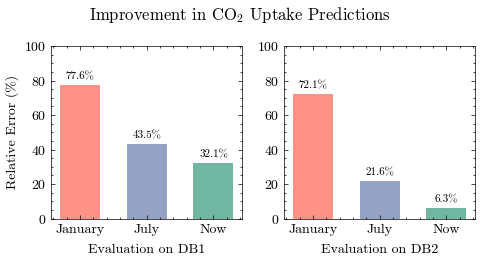

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import scienceplots

# Apply science style
plt.style.use(['science', 'no-latex'])

fig, axes = plt.subplots(1, 2, figsize=(5, 2.8))

# ---------- First plot data ----------
jan1 = 77.6
jul1 = 43.5
now1 = 32.1
values1 = [jan1, jul1, now1]
labels1 = ['January', 'July', 'Now']
colors1 = [colors[4], colors[0], colors[3]]

# Plot 1
axes[0].bar(labels1, values1, color=colors1, width=0.6)
for i, value in enumerate(values1):
    axes[0].text(i, value + 2, f"{value:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[0].set_ylim(0, 100)
# axes[0].set_ylabel("CO$_2$ Uptake Relative Error (%)")
axes[0].set_ylabel("Relative Error (%)")
axes[0].set_xlabel("Evaluation on DB1", fontsize=10, labelpad=6)

# ---------- Second plot data ----------
jan2 = 72.1
jul2 = 21.6
now2 = 6.3
values2 = [jan2, jul2, now2]
labels2 = ['January', 'July', 'Now']
colors2 = [colors[4], colors[0], colors[3]]

# Plot 2
axes[1].bar(labels2, values2, color=colors2, width=0.6)
for i, value in enumerate(values2):
    axes[1].text(i, value + 2, f"{value:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].set_xlabel("Evaluation on DB2", fontsize=10, labelpad=6)

# ---------- Common title ----------
fig.suptitle("Improvement in CO$_2$ Uptake Predictions", fontsize=12, y=0.95)

plt.tight_layout()
# plt.savefig("co2_uptake_comparison.png", dpi=600, bbox_inches='tight')

plt.show()


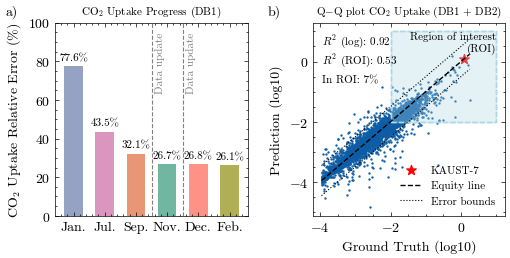

In [25]:
temp = pd.DataFrame({"preds": pred_concat, "gt": gt_concat})
temp = temp[np.log10(temp["gt"]) > -4.0]
fig, axes = plt.subplots(1, 2, figsize=(5.3, 2.8))
axes[1].scatter(x=[0.09], y=[0.09], s=50, color='red', marker='*', label='KAUST-7')
plot_equity_with_band(
    axes[1],
    np.log10(temp['gt']),
    np.log10(temp['preds']),
    title="Q$-$Q plot CO$_2$ Uptake (DB1 + DB2)",
    log=True,
    key="co2_uptake"
)

progress = {"Jan.":77.6,
            "Jul.":43.5,
            "Sep.":32.1,
            "Nov.":26.7,
            "Dec.":26.8,
            "Feb.":26.1
            }

axes[0].bar(progress.keys(), progress.values(), color=colors, width=0.6)
for i, value in progress.items():
    axes[0].text(i, value + 2, f"{value:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].set_title("CO$_2$ Uptake Progress (DB1)", fontsize=8)
axes[0].set_ylabel("CO$_2$ Uptake Relative Error (%)")
axes[0].axvline(x=2.5, color='gray', linestyle='--', linewidth=0.8)
axes[0].axvline(x=3.5, color='gray', linestyle='--', linewidth=0.8)
axes[0].text(2.6, 95, 'Data update', rotation=90, va='top', fontsize=8, color='gray')
axes[0].text(3.6, 95, 'Data update', rotation=90, va='top', fontsize=8, color='gray')
# axes[0].tick_params(axis='x', labelrotation=0)
# for lbl in axes[0].get_xticklabels():
#     lbl.set_ha('right')
axes[0].text(-0.23, 1.06, "a)", fontsize=10, weight='heavy', ha='center', va='center', transform=axes[0].transAxes)
axes[0].text(-0.2, 1.06, "b)", fontsize=10, weight='heavy', ha='center', va='center', transform=axes[1].transAxes)

axes[1].legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("../../temp/figures/co2-uptake-kaust7-jan.png", dpi=300)
plt.show()

In [6]:
merged.head()

,name,co2_uptake_gt,co2_uptake_1,kh_co2_gt,kh_co2_1,qst_gt,qst_1,qst_co2_pred,kh_co2_pred,co2_uptake_pred,qst_co2_pred_denorm,kh_co2_pred_denorm,co2_uptake_pred_denorm
0,sample_362_mepoml,0.000339,0.004005,0.000009,7.665927e-08,-16.793222,0.110691,-17.225077,0.000007,0.000303,-12.589253,-5.125856,-3.517957
1,sample_778_mepoml,0.000505,0.008183,0.000013,1.040476e-08,-12.483744,0.008002,-17.113205,0.000015,0.000592,-12.502927,-4.819672,-3.227551
2,sample_798_mepoml,0.000365,0.008356,0.000009,6.872160e-09,-10.382024,0.005023,-14.060332,0.000009,0.000347,-10.147152,-5.061135,-3.459453
3,sample_798_mepoml,0.000365,0.008356,0.000009,6.872160e-09,-10.382024,0.005023,-14.060328,0.000009,0.000347,-10.147149,-5.061135,-3.459454
4,sample_1006_mepoml,0.000162,0.004388,0.000004,1.513830e-09,-8.080887,0.002079,-12.340775,0.000004,0.000155,-8.820241,-5.407192,-3.808687


# Progress

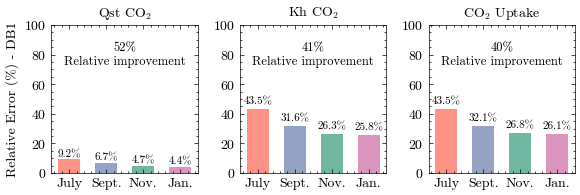

In [34]:

fig, axes = plt.subplots(1, 3, figsize=(6, 2))
# qst_co2
jul1 = 9.2
sep1 = 6.7
nov1 = 4.7
jan1 = 4.4

values1 = [jul1, sep1, nov1, jan1]
labels1 = ['July', 'Sept.', 'Nov.', 'Jan.']
colors1 = [colors[4], colors[0], colors[3], colors[1]]

axes[0].bar(labels1, values1, color=colors1, width=0.6)
for i, value in enumerate(values1):
    axes[0].text(i, value+0.4, f"{value:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[0].set_ylim(0, 100)
# axes[0].set_ylabel("CO$_2$ Uptake Relative Error (%)")
axes[0].set_ylabel("Relative Error (%) - DB1")
# axes[0].set_xlabel("Evaluation on DB1", fontsize=10, labelpad=6)
axes[0].text(0.5, 0.8, "52%\nRelative improvement", transform=axes[0].transAxes,
             ha='center', va='center', fontsize=9, fontweight='bold',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2))

# kh_co2
jul2 = 43.5
sep2 = 31.6
nov2 = 26.3
jan2 = 25.8

values2 = [jul2, sep2, nov2, jan2]
labels2 = ['July', 'Sept.', 'Nov.', 'Jan.']
colors2 = [colors[4], colors[0], colors[3], colors[1]]

axes[1].bar(labels2, values2, color=colors2, width=0.6)
for i, value in enumerate(values2):
    axes[1].text(i, value + 2, f"{value:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1].set_ylim(0, 100)
# axes[1].set_xlabel("Evaluation on DB2", fontsize=10, labelpad=6)
axes[1].text(
    0.5, 0.8,
    "41%\nRelative improvement",
    transform=axes[1].transAxes,
    ha='center',
    va='center',
    fontsize=9,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2)
)


# uptake
jul2 = 43.5
sep2 = 32.1
nov2 = 26.8
jan2 = 26.1

values2 = [jul2, sep2, nov2, jan2]
labels2 = ['July', 'Sept.', 'Nov.', 'Jan.']
colors2 = [colors[4], colors[0], colors[3], colors[1]]

axes[2].bar(labels2, values2, color=colors2, width=0.6)
for i, value in enumerate(values2):
    axes[2].text(i, value + 2, f"{value:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[2].set_ylim(0, 100)
# axes[2].set_xlabel("Evaluation on DB2", fontsize=10, labelpad=6)
axes[2].text(
    0.5, 0.8,
    "40%\nRelative improvement",
    transform=axes[2].transAxes,
    ha='center',
    va='center',
    fontsize=9,
    fontweight='bold',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=2)
)


plt.tight_layout()
# fig.suptitle("Joint Finetuning (DB1-DB2)", fontsize=10, y=1.15)
axes[0].set_title("Qst CO$_2$", fontsize=10, y=1.0)
axes[1].set_title("Kh CO$_2$", fontsize=10, y=1.0)
axes[2].set_title("CO$_2$ Uptake", fontsize=10, y=1.0)

plt.savefig("../../temp/figures/co2_uptake_comparison_jan.png", dpi=300, bbox_inches='tight')

plt.show()


# CO2 vs Water results DB1

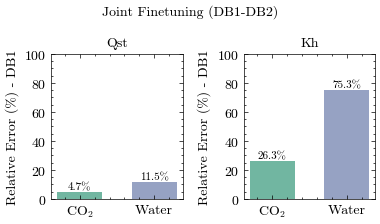

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(4, 2))
# qst
co2 = 4.7
water = 11.5

values1 = [co2, water]
labels1 = ['CO$_2$', 'Water']
colors1 = [colors[3], colors[0]]

axes[0].bar(labels1, values1, color=colors1, width=0.6)
for i, value in enumerate(values1):
    axes[0].text(i, value+0.4, f"{value:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].set_ylabel("Relative Error (%) - DB1")

# kh
co2 = 26.3
water = 75.3

values1 = [co2, water]
labels1 = ['CO$_2$', 'Water']
# colors1 = [colors[0], colors[3]]

axes[1].bar(labels1, values1, color=colors1, width=0.6)
for i, value in enumerate(values1):
    axes[1].text(i, value+0.4, f"{value:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].set_ylabel("Relative Error (%) - DB1")

plt.tight_layout()
fig.suptitle("Joint Finetuning (DB1-DB2)", fontsize=10, y=1.15)
axes[0].set_title("Qst", fontsize=10, y=1.0)
axes[1].set_title("Kh", fontsize=10, y=1.0)
# axes[2].set_title("Uptake", fontsize=10, y=1.0)

plt.savefig("../../temp/figures/co2_and_water.png", dpi=300, bbox_inches='tight')

plt.show()


# 3-by-3 Q-Q plot

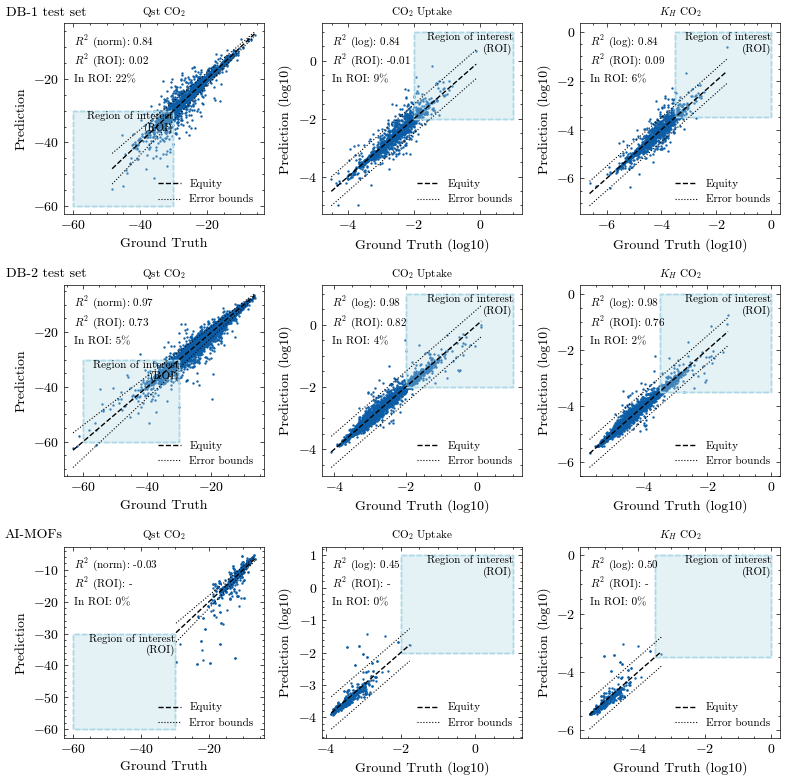

In [63]:
fig, axes = plt.subplots(3, 3, figsize=(8,8))

plot_equity_with_band(
    axes[0,0], 
    db1_qst_co2['pred'],
    db1_qst_co2['gt'],
    key='qst_co2',
    title="Qst CO$_2$",
    log=False
)

plot_equity_with_band(
    axes[0,1],
    np.log10(db1_co2_uptake['pred']),
    np.log10(db1_co2_uptake['gt']),
    key='co2_uptake',
    title="CO$_2$ Uptake",
    log=True
)

plot_equity_with_band(
    axes[0,2],
    np.log10(db1_kh_co2['pred']),
    np.log10(db1_kh_co2['gt']),
    key='kh_co2',
    title="$K_H$ CO$_2$",
    log=True
)

plot_equity_with_band(
    axes[1,0],
    db2_qst_co2['pred'],
    db2_qst_co2['gt'],
    title="Qst CO$_2$",
    log=False,
    key="qst_co2"
)

plot_equity_with_band(
    axes[1,1],
    np.log10(db2_co2_uptake['pred']),
    np.log10(db2_co2_uptake['gt']),
    title="CO$_2$ Uptake",
    log=True,
    key="co2_uptake"
)

plot_equity_with_band(
    axes[1,2],
    np.log10(db2_kh_co2['pred']),
    np.log10(db2_kh_co2['gt']),
    title="$K_H$ CO$_2$",
    log=True,
    key="kh_co2"
)

plot_equity_with_band(
    axes[2,0],
    merged['qst_co2_pred_denorm'],
    merged['qst_gt'],
    key="qst_co2",
    title="Qst CO$_2$",
)

plot_equity_with_band(
    axes[2,1],
    merged['co2_uptake_pred_denorm'],
    np.log10(merged['co2_uptake_gt']),
    title="CO$_2$ Uptake",
    log=True,
    key="co2_uptake"
)
plot_equity_with_band(
    axes[2,2],
    merged['kh_co2_pred_denorm'],
    np.log10(merged['kh_co2_gt']),
    title="$K_H$ CO$_2$",
    log=True,
    key="kh_co2"
)
# plt.rcParams['font.weight'] = 'bold'
axes[0,0].text(-80, 0, s='DB-1 test set', fontsize=10, weight='bold',ha='left')
axes[1,0].text(-84, 0, s='DB-2 test set', fontsize=10, weight='bold',ha='left')
axes[2,0].text(-80, 0, s='AI-MOFs', fontsize=10, weight='bold',ha='left')
plt.tight_layout()
# plt.savefig("temp/figures/best-model-comparison.png", dpi=300)
plt.show()

# All splits together

In [43]:
import numpy as np 
import pandas as pd 
# DB1 data test
db1_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB1/co2_uptake.npz', allow_pickle=True)
db1_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB1/kh_co2.npz', allow_pickle=True)
db1_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB1/qst_co2.npz', allow_pickle=True)
db1_test = [db1_co2_uptake, db1_kh_co2, db1_qst_co2]

df = pd.DataFrame({
    "mof_id": db1_qst_co2["sid"],
    "qst_co2_pred": db1_qst_co2["pred"],
    "qst_co2_gt": db1_qst_co2["gt"],
    "kh_co2_pred": db1_kh_co2["pred"],
    "kh_co2_gt": db1_kh_co2["gt"],
    "co2_uptake_pred": db1_co2_uptake["pred"],
    "co2_uptake_gt": db1_co2_uptake["gt"],
})
df['db'] = 'DB1'
df['split'] = 'test'

merged = df.copy()
print("DB1, test")
print("DF size: ", len(df))
print(len(merged))
# DB2 data test 
db2_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB2/co2_uptake.npz', allow_pickle=True)
db2_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB2/kh_co2.npz', allow_pickle=True)
db2_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB2/qst_co2.npz', allow_pickle=True)
db2_test = [db2_co2_uptake, db2_kh_co2, db2_qst_co2]


df = pd.DataFrame({
    "mof_id": db2_qst_co2["sid"],
    "qst_co2_pred": db2_qst_co2["pred"],
    "qst_co2_gt": db2_qst_co2["gt"],
    "kh_co2_pred": db2_kh_co2["pred"],
    "kh_co2_gt": db2_kh_co2["gt"],
    "co2_uptake_pred": db2_co2_uptake["pred"],
    "co2_uptake_gt": db2_co2_uptake["gt"],
})
df['db'] = 'DB2'
df['split'] = 'test'

merged = pd.concat([merged, df], axis=0, ignore_index=True)
print("DB2, test")
print("DF size: ", len(df))
print(len(merged))

# DB1 data val
db1_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/val/DB1/co2_uptake.npz', allow_pickle=True)
db1_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/val/DB1/kh_co2.npz', allow_pickle=True)
db1_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/val/DB1/qst_co2.npz', allow_pickle=True)
db1_val = [db1_co2_uptake, db1_kh_co2, db1_qst_co2]

df = pd.DataFrame({
    "mof_id": db1_qst_co2["sid"],
    "qst_co2_pred": db1_qst_co2["pred"],
    "qst_co2_gt": db1_qst_co2["gt"],
    "kh_co2_pred": db1_kh_co2["pred"],
    "kh_co2_gt": db1_kh_co2["gt"],
    "co2_uptake_pred": db1_co2_uptake["pred"],
    "co2_uptake_gt": db1_co2_uptake["gt"],
})
df['db'] = 'DB1'
df['split'] = 'val'
merged = pd.concat([merged, df], axis=0, ignore_index=True)
print("DB1, val")
print("DF size: ", len(df))
print(len(merged))

# DB2 data val 
db2_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/val/DB2/co2_uptake.npz', allow_pickle=True)
db2_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/val/DB2/kh_co2.npz', allow_pickle=True)
db2_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/val/DB2/qst_co2.npz', allow_pickle=True)
db2_val = [db2_co2_uptake, db2_kh_co2, db2_qst_co2]

df = pd.DataFrame({
    "mof_id": db2_qst_co2["sid"],
    "qst_co2_pred": db2_qst_co2["pred"],
    "qst_co2_gt": db2_qst_co2["gt"],
    "kh_co2_pred": db2_kh_co2["pred"],
    "kh_co2_gt": db2_kh_co2["gt"],
    "co2_uptake_pred": db2_co2_uptake["pred"],
    "co2_uptake_gt": db2_co2_uptake["gt"],
})
df['db'] = 'DB2'
df['split'] = 'val'
merged = pd.concat([merged, df], axis=0, ignore_index=True)
print("DB2, val")
print("DF size: ", len(df))
print(len(merged))

# # DB1 data train
# db1_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/train/DB1/co2_uptake.npz', allow_pickle=True)
# db1_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/train/DB1/kh_co2.npz', allow_pickle=True)
# db1_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/train/DB1/qst_co2.npz', allow_pickle=True)
# db1_train = [db1_co2_uptake, db1_kh_co2, db1_qst_co2]

# df = pd.DataFrame({
#     "mof_id": db1_qst_co2["sid"],
#     "qst_co2_pred": db1_qst_co2["pred"],
#     "qst_co2_gt": db1_qst_co2["gt"],
#     "kh_co2_pred": db1_kh_co2["pred"],
#     "kh_co2_gt": db1_kh_co2["gt"],
#     "co2_uptake_pred": db1_co2_uptake["pred"],
#     "co2_uptake_gt": db1_co2_uptake["gt"],
# })
# df['db'] = 'DB1'
# df['split'] = 'train'
# merged = pd.concat([merged, df], axis=0, ignore_index=True)
# print("DB1, train")
# print("DF size: ", len(df))
# print(len(merged))

# # DB2 data train
# db2_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/train/DB2/co2_uptake.npz', allow_pickle=True)
# db2_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/train/DB2/kh_co2.npz', allow_pickle=True)
# db2_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/train/DB2/qst_co2.npz', allow_pickle=True)
# db2_train = [db2_co2_uptake, db2_kh_co2, db2_qst_co2]

# df = pd.DataFrame({
#     "mof_id": db2_qst_co2["sid"],
#     "qst_co2_pred": db2_qst_co2["pred"],
#     "qst_co2_gt": db2_qst_co2["gt"],
#     "kh_co2_pred": db2_kh_co2["pred"],
#     "kh_co2_gt": db2_kh_co2["gt"],
#     "co2_uptake_pred": db2_co2_uptake["pred"],
#     "co2_uptake_gt": db2_co2_uptake["gt"],
# })
# df['db'] = 'DB2'
# df['split'] = 'train'
old_merged = pd.concat([merged, df], axis=0, ignore_index=True)
print("DB2, train")
print("DF size: ", len(df))
print(len(merged))
old_merged.drop_duplicates(subset=['mof_id'], keep='first', inplace=True)
print(len(old_merged))

DB1, test
DF size:  4864
4864
DB2, test
DF size:  9891
14755
DB1, val
DF size:  2407
17162
DB2, val
DF size:  4988
22150
DB2, train
DF size:  4988
22150
22150


In [44]:
import numpy as np 
import pandas as pd 
# DB1 data test
db1_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB1/co2_uptake.npz', allow_pickle=True)
db1_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB1/kh_co2.npz', allow_pickle=True)
db1_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB1/qst_co2.npz', allow_pickle=True)
db1_qst_h2o = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB1/qst_h2o.npz', allow_pickle=True)
db1_kh_h2o = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB1/kh_h2o.npz', allow_pickle=True)
db1_test = [db1_co2_uptake, db1_kh_co2, db1_qst_co2, db1_qst_h2o, db1_kh_h2o]

df = pd.DataFrame({
    "mof_id": db1_qst_co2["sid"],
    "qst_co2_pred": db1_qst_co2["pred"],
    "qst_co2_gt": db1_qst_co2["gt"],
    "kh_co2_pred": db1_kh_co2["pred"],
    "kh_co2_gt": db1_kh_co2["gt"],
    "co2_uptake_pred": db1_co2_uptake["pred"],
    "co2_uptake_gt": db1_co2_uptake["gt"],
    "h2o_qst_pred": db1_qst_h2o["pred"],
    "h2o_qst_gt": db1_qst_h2o["gt"],
    "kh_h2o_pred": db1_kh_h2o["pred"],
    "kh_h2o_gt": db1_kh_h2o["gt"],
})
df['db'] = 'DB1'
df['split'] = 'test'

merged = df.copy()
print("DB1, test")
print("DF size: ", len(df))
print(len(merged))

# DB2 data test 
db2_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB2/co2_uptake.npz', allow_pickle=True)
db2_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB2/kh_co2.npz', allow_pickle=True)
db2_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB2/qst_co2.npz', allow_pickle=True)
db2_qst_h2o = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB2/qst_h2o.npz', allow_pickle=True)
db2_kh_h2o = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/test/DB2/kh_h2o.npz', allow_pickle=True)
db2_test = [db2_co2_uptake, db2_kh_co2, db2_qst_co2, db2_qst_h2o, db2_kh_h2o]


df = pd.DataFrame({
    "mof_id": db2_qst_co2["sid"],
    "qst_co2_pred": db2_qst_co2["pred"],
    "qst_co2_gt": db2_qst_co2["gt"],
    "kh_co2_pred": db2_kh_co2["pred"],
    "kh_co2_gt": db2_kh_co2["gt"],
    "co2_uptake_pred": db2_co2_uptake["pred"],
    "co2_uptake_gt": db2_co2_uptake["gt"],
    "h2o_qst_pred": db2_qst_h2o["pred"],
    "h2o_qst_gt": db2_qst_h2o["gt"],
    "kh_h2o_pred": db2_kh_h2o["pred"],
    "kh_h2o_gt": db2_kh_h2o["gt"],
})
df['db'] = 'DB2'
df['split'] = 'test'

merged = pd.concat([merged, df], axis=0, ignore_index=True)
print("DB2, test")
print("DF size: ", len(df))
print(len(merged))

# DB1 data val
db1_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/val/DB1/co2_uptake.npz', allow_pickle=True)
db1_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/val/DB1/kh_co2.npz', allow_pickle=True)
db1_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/val/DB1/qst_co2.npz', allow_pickle=True)
db1_qst_h2o = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/val/DB1/qst_h2o.npz', allow_pickle=True)
db1_kh_h2o = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/val/DB1/kh_h2o.npz', allow_pickle=True)
db1_val = [db1_co2_uptake, db1_kh_co2, db1_qst_co2, db1_qst_h2o, db1_kh_h2o]

df = pd.DataFrame({
    "mof_id": db1_qst_co2["sid"],
    "qst_co2_pred": db1_qst_co2["pred"],
    "qst_co2_gt": db1_qst_co2["gt"],
    "kh_co2_pred": db1_kh_co2["pred"],
    "kh_co2_gt": db1_kh_co2["gt"],
    "co2_uptake_pred": db1_co2_uptake["pred"],
    "co2_uptake_gt": db1_co2_uptake["gt"],
    "h2o_qst_pred": db1_qst_h2o["pred"],
    "h2o_qst_gt": db1_qst_h2o["gt"],
    "kh_h2o_pred": db1_kh_h2o["pred"],
    "kh_h2o_gt": db1_kh_h2o["gt"],
})
df['db'] = 'DB1'
df['split'] = 'val'
merged = pd.concat([merged, df], axis=0, ignore_index=True)
print("DB1, val")
print("DF size: ", len(df))
print(len(merged))

# DB2 data val 
db2_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/val/DB2/co2_uptake.npz', allow_pickle=True)
db2_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/val/DB2/kh_co2.npz', allow_pickle=True)
db2_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/val/DB2/qst_co2.npz', allow_pickle=True)
db2_qst_h2o = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/val/DB2/qst_h2o.npz', allow_pickle=True)
db2_kh_h2o = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/val/DB2/kh_h2o.npz', allow_pickle=True)
db2_val = [db2_co2_uptake, db2_kh_co2, db2_qst_co2, db2_qst_h2o, db2_kh_h2o]

df = pd.DataFrame({
    "mof_id": db2_qst_co2["sid"],
    "qst_co2_pred": db2_qst_co2["pred"],
    "qst_co2_gt": db2_qst_co2["gt"],
    "kh_co2_pred": db2_kh_co2["pred"],
    "kh_co2_gt": db2_kh_co2["gt"],
    "co2_uptake_pred": db2_co2_uptake["pred"],
    "co2_uptake_gt": db2_co2_uptake["gt"],
    "h2o_qst_pred": db2_qst_h2o["pred"],
    "h2o_qst_gt": db2_qst_h2o["gt"],
    "kh_h2o_pred": db2_kh_h2o["pred"],
    "kh_h2o_gt": db2_kh_h2o["gt"],
})
df['db'] = 'DB2'
df['split'] = 'val'
merged = pd.concat([merged, df], axis=0, ignore_index=True)
print("DB2, val")
print("DF size: ", len(df))
print(len(merged))

# # DB1 data train
# db1_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/train/DB1/co2_uptake.npz', allow_pickle=True)
# db1_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/train/DB1/kh_co2.npz', allow_pickle=True)
# db1_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/train/DB1/qst_co2.npz', allow_pickle=True)
# db1_qst_h2o = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/train/DB1/qst_h2o.npz', allow_pickle=True)
# db1_kh_h2o = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/train/DB1/kh_h2o.npz', allow_pickle=True)
# db1_train = [db1_co2_uptake, db1_kh_co2, db1_qst_co2, db1_qst_h2o, db1_kh_h2o]

# df = pd.DataFrame({
#     "mof_id": db1_qst_co2["sid"],
#     "qst_co2_pred": db1_qst_co2["pred"],
#     "qst_co2_gt": db1_qst_co2["gt"],
#     "kh_co2_pred": db1_kh_co2["pred"],
#     "kh_co2_gt": db1_kh_co2["gt"],
#     "co2_uptake_pred": db1_co2_uptake["pred"],
#     "co2_uptake_gt": db1_co2_uptake["gt"],
#     "h2o_qst_pred": db1_qst_h2o["pred"],
#     "h2o_qst_gt": db1_qst_h2o["gt"],
#     "kh_h2o_pred": db1_kh_h2o["pred"],
#     "kh_h2o_gt": db1_kh_h2o["gt"],
# })
# df['db'] = 'DB1'
# df['split'] = 'train'
# merged = pd.concat([merged, df], axis=0, ignore_index=True)
# print("DB1, train")
# print("DF size: ", len(df))
# print(len(merged))

# # DB2 data train
# db2_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/train/DB2/co2_uptake.npz', allow_pickle=True)
# db2_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/train/DB2/kh_co2.npz', allow_pickle=True)
# db2_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/train/DB2/qst_co2.npz', allow_pickle=True)
# db2_qst_h2o = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/train/DB2/qst_h2o.npz', allow_pickle=True)
# db2_kh_h2o = np.load('/ibex/project/c2261/dac_iclr/finetune/lightning_logs/yozti0u8/predictions/version_yozti0u8/final/train/DB2/kh_h2o.npz', allow_pickle=True)
# db2_train = [db2_co2_uptake, db2_kh_co2, db2_qst_co2, db2_qst_h2o, db2_kh_h2o]

# df = pd.DataFrame({
#     "mof_id": db2_qst_co2["sid"],
#     "qst_co2_pred": db2_qst_co2["pred"],
#     "qst_co2_gt": db2_qst_co2["gt"],
#     "kh_co2_pred": db2_kh_co2["pred"],
#     "kh_co2_gt": db2_kh_co2["gt"],
#     "co2_uptake_pred": db2_co2_uptake["pred"],
#     "co2_uptake_gt": db2_co2_uptake["gt"],
#     "h2o_qst_pred": db2_qst_h2o["pred"],
#     "h2o_qst_gt": db2_qst_h2o["gt"],
#     "kh_h2o_pred": db2_kh_h2o["pred"],
#     "kh_h2o_gt": db2_kh_h2o["gt"],
# })
# df['db'] = 'DB2'
# df['split'] = 'train'
# merged = pd.concat([merged, df], axis=0, ignore_index=True)
# print("DB2, train")
# print("DF size: ", len(df))
# print(len(merged))
merged.drop_duplicates(subset=['mof_id'], keep='first', inplace=True)
print(len(merged))

DB1, test
DF size:  4864
4864
DB2, test
DF size:  9891
14755
DB1, val
DF size:  2407
17162
DB2, val
DF size:  4988
22150
22150


In [45]:
print(len(merged))

22150


In [38]:
def smape(x, y, eps=1e-8):
    x, y = np.array(x), np.array(y)
    denominator = (np.abs(x) + np.abs(y)) / 2.0
    return np.mean(np.abs(y - x) / (denominator + eps)) * 100

def plot_equity_with_band_overlayed(ax, x, y, title, df, colors, log=False, key=None):
    REGION_OF_INTEREST = {
        'qst_co2': [-30, -60],        
        'kh_co2':  [-3.5, 0],        
        'co2_uptake': [-2, 1],        
        'qst_h2o': [-40, -80],        
        'kh_h2o':  [-2, 1],           
        'selectivity_co2_h2o': [0, 3],
        }

    for split, _color in zip(['val', 'test', 'train'], [colors[0], colors[1], colors[3]]):
        if not log:
            ax.scatter(df[df['split'] == split][f'{key}_gt'], df[df['split'] == split][f'{key}_pred'], s=0.5, color=_color, label=split)
            ax.set_title(split + " " + title, fontsize=8)
        else:
            ax.scatter(np.log10(df[df['split'] == split][f'{key}_gt']), np.log10(df[df['split'] == split][f'{key}_pred']), s=0.5, color=_color, label=split)
            ax.set_title(split + " " + title, fontsize=8)
    r2 = r2_score(x, y)

    minv, maxv = x.min(), x.max()
    ax.plot([minv, maxv], [minv, maxv], 'k--', lw=1, label="Equity line")

    if log:
        upper = np.array([minv, maxv]) + 0.5
        lower = np.array([minv, maxv]) - 0.5
        _y = np.exp(y)
        _x = np.exp(x)
        smape_error = smape(_x, _y)

    else:
        upper = 1.1 * np.array([minv, maxv])
        lower = 0.9 * np.array([minv, maxv])
        smape_error = smape(x, y)        

    # ax.plot([minv, maxv], upper, 'k:', lw=0.8, label="Error bounds")
    # ax.plot([minv, maxv], lower, 'k:', lw=0.8)

    slope = (upper[1] - upper[0]) / (maxv - minv)
    upper_line = upper[0] + slope * (x - minv)
    lower_line = lower[0] + slope * (x - minv)

    outside = np.sum((y > upper_line) | (y < lower_line))

    ax.set_xlabel("Ground Truth" + (" (log10)" if log else ""), fontsize=8)
    ax.set_ylabel("Prediction" + (" (log10)" if log else ""), fontsize=8)
    if log:
        ax.text(0.05, 0.95, f"$R^2$ (log): {r2:.2f}", transform=ax.transAxes,va="top", ha="left", fontsize=8)
    else:
        ax.text(0.05, 0.95, f"$R^2$ (norm): {r2:.2f}", transform=ax.transAxes,va="top", ha="left", fontsize=8)
    if key is not None and key in REGION_OF_INTEREST:
        rx0, rx1 = REGION_OF_INTEREST[key]
        ry0, ry1 = REGION_OF_INTEREST[key]
        x0, x1 = (rx0, rx1) if rx0 <= rx1 else (rx1, rx0)
        y0, y1 = (ry0, ry1) if ry0 <= ry1 else (ry1, ry0)

        ax.fill_between([rx0, rx1], ry0, ry1, color="lightblue", alpha=0.15)
        ax.add_patch(
            plt.Rectangle((rx0, ry0), rx1 - rx0, ry1 - ry0,
                          fill=False, edgecolor="lightblue", lw=1.0, linestyle="--")
        )

        roi_mask = (x >= x0) & (x <= x1) & (y >= y0) & (y <= y1)
        in_roi = int(roi_mask.sum())
        r2_roi = np.nan
        if in_roi >= 2:
            r2_roi = r2_score(x[roi_mask], y[roi_mask])

        ax.text(0.05, 0.85,
                f"$R^2$ (ROI): {r2_roi:.2f}" if in_roi >= 2 else "$R^2$ (ROI): -",
                transform=ax.transAxes, va="top", ha="left", fontsize=8)
        ax.text(0.05, 0.73,
                f"In ROI: {in_roi/len(y):.0%}",
                transform=ax.transAxes, va="top", ha="left", fontsize=8)

    if key is not None and key in REGION_OF_INTEREST:
        roi_xmin, roi_xmax = REGION_OF_INTEREST[key]
        roi_ymin, roi_ymax = REGION_OF_INTEREST[key]
        ax.fill_between(
            [roi_xmin, roi_xmax],
            roi_ymin, roi_ymax,
            color="lightblue", alpha=0.2,
        )
        ax.add_patch(
            plt.Rectangle(
                (roi_xmin, roi_ymin),
                roi_xmax - roi_xmin,
                roi_ymax - roi_ymin,
                fill=False, edgecolor="lightblue", lw=1.0, linestyle="--"
            )
        )
    if log:
        ax.text(
            x=roi_xmax,
            y=roi_ymax,
            s="Region of interest\n(ROI)",
            fontsize=8,
            va="top",
            ha="right",
        )
    else:
        ax.text(
            x=roi_xmax,
            y=roi_ymin,
            s="Region of interest\n(ROI)",
            fontsize=8,
            va="top",
            ha="left",
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0)
        )
    axes[0].scatter(x=[-56], y=[-56], s=50, color='red', marker='*', label='KAUST-7')
    axes[1].scatter(x=[0.16], y=[0.16], s=50, color='red', marker='*', label='KAUST-7')
    axes[2].scatter(x=[-1.48], y=[-1.48], s=50, color='red', marker='*', label='KAUST-7')
    handles = [
        # Line2D([0], [0], color='k', linestyle='--', lw=1, label='Equity'),
        # Line2D([0], [0], color='k', linestyle=':', lw=0.8, label='Error (10%)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[0], markersize=6, label='val'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[1], markersize=6, label='test'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[3], markersize=6, label='train'),
        Line2D([0], [0], marker='*', color='w', markerfacecolor="red", markersize=10, label='KAUST-7'),

    ]
    ax.legend(handles=handles, loc="lower right", fontsize=8)

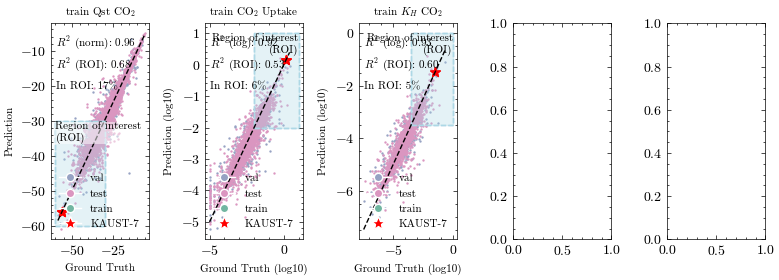

In [39]:
fig, axes = plt.subplots(1, 5, figsize=(8,3))

plot_equity_with_band_overlayed(
    axes[0], 
    merged['qst_co2_gt'],
    merged['qst_co2_pred'],
    key='qst_co2',
    title="Qst CO$_2$",
    log=False,
    colors=colors,
    df=merged
)

plot_equity_with_band_overlayed(
    axes[1],
    np.log10(merged['co2_uptake_gt']),
    np.log10(merged['co2_uptake_pred']),
    key='co2_uptake',
    title="CO$_2$ Uptake",
    log=True,
    colors=colors,
    df=merged
)

plot_equity_with_band_overlayed(
    axes[2],
    np.log10(merged['kh_co2_gt']),
    np.log10(merged['kh_co2_pred']),
    key='kh_co2',
    title="$K_H$ CO$_2$",
    log=True,
    colors=colors,
    df=merged
)
# axes[1].text(0.09, 0.5, s='KAUST-7', fontsize=8, weight='bold',ha='left', color='red')

# plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig("/home/ignaczg/projects/aramco_dac/temp/figures/all_data_comparison_280k_results_jan.png", dpi=300)
plt.show()

In [47]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np
import scienceplots
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.style.use(['science', 'no-latex'])


def smape(x, y, eps=1e-8):
    x, y = np.array(x), np.array(y)
    denominator = (np.abs(x) + np.abs(y)) / 2.0

    return np.mean(np.abs(y - x) / (denominator + eps)) * 100

def plot_equity_with_band(ax, gt, pred, title, log=False, key=None, stats=True, color_label=None, x_old=None, y_old=None):
    x = gt
    y = pred
    
    REGION_OF_INTEREST = {
        'qst_co2': [-30, -60],        
        'kh_co2':  [-3.5, 0],        
        'co2_uptake': [-2, 1],        
        'qst_h2o': [-40, -80],        
        'kh_h2o':  [-2, 1],           
        'selectivity_co2_h2o': [0, 3],
        }
    
    if color_label is not None:
        unique_labels = np.unique(color_label)
        cmap = plt.get_cmap('Set1')
        colmap = {_name: i for i, _name in enumerate(unique_labels)}

        point_colors = [cmap(colmap[_name]) for _name in color_label]

        ax.scatter(
            x,
            y,
            s=1,
            c=point_colors,
        )
    else:
        ax.scatter(x, y, s=1, color='C0', alpha=0.7)

    if x_old is not None and y_old is not None:
        r2_old = r2_score(y_true=x_old, y_pred=y_old)
    else:
        r2_old = None


    if x_old is not None and y_old is not None:
        try:
            r2_old = r2_score(y_true=x_old, y_pred=y_old) if (x_old.size > 0 and y_old.size > 0) else None
        except Exception:
            r2_old = None


    r2 = r2_score(y_true=x, y_pred=y)
    print(f"{title} R2: {r2:.4f}")
    mae = np.mean(np.abs(x - y))
    minv, maxv = x.min(), x.max()
    ax.plot([minv, maxv], [minv, maxv], 'k--', lw=1, label="Equity line")

    if log:
        upper = np.array([minv, maxv]) + 0.5
        lower = np.array([minv, maxv]) - 0.5
        _y = np.exp(y)
        _x = np.exp(x)
        smape_error = smape(_x, _y)

    else:
        upper = 1.1 * np.array([minv, maxv])
        lower = 0.9 * np.array([minv, maxv])
        smape_error = smape(x, y)        

    ax.plot([minv, maxv], upper, 'k:', lw=0.8, label="Error bounds")
    ax.plot([minv, maxv], lower, 'k:', lw=0.8)

    slope = (upper[1] - upper[0]) / (maxv - minv)
    upper_line = upper[0] + slope * (x - minv)
    lower_line = lower[0] + slope * (x - minv)

    outside = np.sum((y > upper_line) | (y < lower_line))

    ax.set_xlabel("Ground Truth" + (" (log10)" if log else ""))
    ax.set_ylabel("Prediction" + (" (log10)" if log else ""))
    ax.set_title(title, fontsize=8)
    if stats:
        if log:
            if r2_old is not None:
                ax.text(0.05, 0.95, f"$R^2$ (log): {r2:.2f} ({r2_old:.2f})", transform=ax.transAxes,va="top", ha="left", fontsize=8)
            else:
                ax.text(0.05, 0.95, f"$R^2$ (log): {r2:.2f}", transform=ax.transAxes,va="top", ha="left", fontsize=8)
                # ax.text(0.05, 0.85, f"MAE: {mae:.2f}", transform=ax.transAxes,va="top", ha="left", fontsize=8)
        else:
            if r2_old is not None:
                ax.text(0.05, 0.95, f"$R^2$ (norm): {r2:.2f} ({r2_old:.2f})", transform=ax.transAxes,va="top", ha="left", fontsize=8 )
            else:
                ax.text(0.05, 0.95, f"$R^2$ (norm): {r2:.2f}", transform=ax.transAxes,va="top", ha="left", fontsize=8 )
                # ax.text(0.05, 0.85, f"MAE: {mae:.2f}", transform=ax.transAxes,va="top", ha="left", fontsize=8)

                
        if key is not None and key in REGION_OF_INTEREST:
            rx0, rx1 = REGION_OF_INTEREST[key]
            ry0, ry1 = REGION_OF_INTEREST[key]
            x0, x1 = (rx0, rx1) if rx0 <= rx1 else (rx1, rx0)
            y0, y1 = (ry0, ry1) if ry0 <= ry1 else (ry1, ry0)

            ax.fill_between([rx0, rx1], ry0, ry1, color="lightblue", alpha=0.15)
            ax.add_patch(
                plt.Rectangle((rx0, ry0), rx1 - rx0, ry1 - ry0,
                            fill=False, edgecolor="lightblue", lw=1.0, linestyle="--")
            )

            roi_mask = (x >= x0) & (x <= x1) & (y >= y0) & (y <= y1)
            in_roi = int(roi_mask.sum())
            r2_roi = np.nan
            if in_roi >= 2:
                r2_roi = r2_score(x[roi_mask], y[roi_mask])
            if x_old is not None and y_old is not None:
                roi_mask_old = (x_old >= x0) & (x_old <= x1) & (y_old >= y0) & (y_old <= y1)
                in_roi_old = int(roi_mask_old.sum())
                r2_roi_old = np.nan
                if in_roi_old >= 2:
                    r2_roi_old = r2_score(x_old[roi_mask_old], y_old[roi_mask_old])
            else:
                r2_roi_old = None

            if r2_roi_old is not None:
                ax.text(0.05, 0.85,
                        f"$R^2$ (ROI): {r2_roi:.2f} ({r2_roi_old:.2f})" if in_roi >= 2 else "$R^2$ (ROI): -",
                        transform=ax.transAxes, va="top", ha="left", fontsize=8)
                ax.text(0.05, 0.73,
                        f"In ROI: {in_roi/len(y):.0%}",
                        transform=ax.transAxes, va="top", ha="left", fontsize=8)
            else:
                ax.text(0.05, 0.85,
                        f"$R^2$ (ROI): {r2_roi:.2f}" if in_roi >= 2 else "$R^2$ (ROI): -",
                        transform=ax.transAxes, va="top", ha="left", fontsize=8)
                ax.text(0.05, 0.73,
                        f"In ROI: {in_roi/len(y):.0%}",
                        transform=ax.transAxes, va="top", ha="left", fontsize=8)
    
        if key is not None and key in REGION_OF_INTEREST:
            roi_xmin, roi_xmax = REGION_OF_INTEREST[key]
            roi_ymin, roi_ymax = REGION_OF_INTEREST[key]
            ax.fill_between(
                [roi_xmin, roi_xmax],
                roi_ymin, roi_ymax,
                color="lightblue", alpha=0.2,
            )
            ax.add_patch(
                plt.Rectangle(
                    (roi_xmin, roi_ymin),
                    roi_xmax - roi_xmin,
                    roi_ymax - roi_ymin,
                    fill=False, edgecolor="lightblue", lw=1.0, linestyle="--"
                )
            )

        # if log:
        #     ax.text(
        #         x=roi_xmax,
        #         y=roi_ymax,
        #         s="Region of interest\n(ROI)",
        #         fontsize=8,
        #         va="top",
        #         ha="right",
        #     )
        # else:
        #     ax.text(
        #         x=roi_xmax,
        #         y=roi_ymax,
        #         s="Region of interest\n(ROI)",
        #         fontsize=8,
        #         va="bottom",
        #         ha="left",
        #     )

        
        handles = [
            Line2D([0], [0], color='k', linestyle='--', lw=1, label='Equity'),
            Line2D([0], [0], color='k', linestyle=':', lw=0.8, label='Error bounds'),
            # Patch(facecolor='lightblue', alpha=0.2, label='ROI')
        ]

        if color_label is not None:
            unique_labels = np.unique(color_label)
            cmap = plt.get_cmap('Set1')
            colmap = {_name: i for i, _name in enumerate(unique_labels)}
            for name in unique_labels:
                idx = colmap[name]
                handles.append(
                    Line2D(
                        [0], [0],
                        marker='o',
                        linestyle='',
                        color=cmap(idx),
                        label="Batch "+str(name),
                        markersize=4,
                    )
                )
        ax.legend(handles=handles, loc="lower right", fontsize=8)




Validation Qst CO$_2$ R2: 0.9557
Validation CO$_2$ Uptake R2: 0.9077
Validation $K_H$ CO$_2$ R2: 0.9251
Test Qst CO$_2$ R2: 0.9601
Test CO$_2$ Uptake R2: 0.9098
Test $K_H$ CO$_2$ R2: 0.9277
Test Qst H$_2$O R2: 0.8521
Test $K_H$ H$_2$O R2: 0.8380
Validation Qst H$_2$O R2: 0.8610
Validation $K_H$ H$_2$O R2: 0.8450


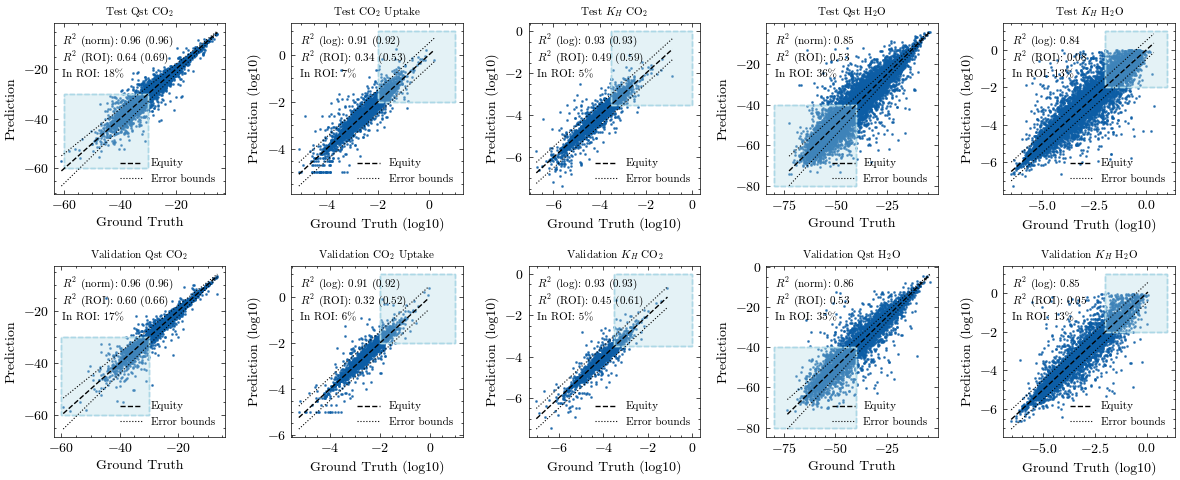

In [48]:
fig, axes = plt.subplots(2, 5, figsize=(12,5))

# plot_equity_with_band(
#     axes[0,0], 
#     merged[merged['split'] == 'train']['qst_co2_pred'],
#     merged[merged['split'] == 'train']['qst_co2_gt'],
#     key='qst_co2',
#     title="Train Qst CO$_2$",
#     log=False,
#     y_old=old_merged[old_merged['split'] == 'train']['qst_co2_pred'],
#     x_old=old_merged[old_merged['split'] == 'train']['qst_co2_gt'],
# )

# plot_equity_with_band(
#     axes[0,1],
#     np.log10(merged[merged['split'] == 'train']['co2_uptake_pred']),
#     np.log10(merged[merged['split'] == 'train']['co2_uptake_gt']),
#     key='co2_uptake',
#     title="Train CO$_2$ Uptake",
#     log=True,
#     y_old=np.log10(old_merged[old_merged['split'] == 'train']['co2_uptake_pred']),
#     x_old=np.log10(old_merged[old_merged['split'] == 'train']['co2_uptake_gt']),
# )

# plot_equity_with_band(
#     axes[0,2],
#     np.log10(merged[merged['split'] == 'train']['kh_co2_pred']),
#     np.log10(merged[merged['split'] == 'train']['kh_co2_gt']),
#     key='kh_co2',
#     title="$Train K_H$ CO$_2$",
#     log=True,
#     y_old=np.log10(old_merged[old_merged['split'] == 'train']['kh_co2_pred']),
#     x_old=np.log10(old_merged[old_merged['split'] == 'train']['kh_co2_gt']),
# )

plot_equity_with_band(
    axes[1,0], 
    merged[merged['split'] == 'val']['qst_co2_pred'],
    merged[merged['split'] == 'val']['qst_co2_gt'],
    key='qst_co2',
    title="Validation Qst CO$_2$",
    log=False,
    y_old=old_merged[old_merged['split'] == 'val']['qst_co2_pred'],
    x_old=old_merged[old_merged['split'] == 'val']['qst_co2_gt'],
)

plot_equity_with_band(
    axes[1,1],
    np.log10(merged[merged['split'] == 'val']['co2_uptake_pred']),
    np.log10(merged[merged['split'] == 'val']['co2_uptake_gt']),
    key='co2_uptake',
    title="Validation CO$_2$ Uptake",
    log=True,
    y_old=np.log10(old_merged[old_merged['split'] == 'val']['co2_uptake_pred']),
    x_old=np.log10(old_merged[old_merged['split'] == 'val']['co2_uptake_gt']),

)

plot_equity_with_band(
    axes[1,2],
    np.log10(merged[merged['split'] == 'val']['kh_co2_pred']),
    np.log10(merged[merged['split'] == 'val']['kh_co2_gt']),
    key='kh_co2',
    title="Validation $K_H$ CO$_2$",
    log=True,
    y_old=np.log10(old_merged[old_merged['split'] == 'val']['kh_co2_pred']),
    x_old=np.log10(old_merged[old_merged['split'] == 'val']['kh_co2_gt']),
)



plot_equity_with_band(
    axes[0,0], 
    merged[merged['split'] == 'test']['qst_co2_pred'],
    merged[merged['split'] == 'test']['qst_co2_gt'],
    key='qst_co2',
    title="Test Qst CO$_2$",
    log=False,
    y_old=old_merged[old_merged['split'] == 'test']['qst_co2_pred'],
    x_old=old_merged[old_merged['split'] == 'test']['qst_co2_gt'],
)

plot_equity_with_band(
    axes[0,1],
    np.log10(merged[merged['split'] == 'test']['co2_uptake_pred']),
    np.log10(merged[merged['split'] == 'test']['co2_uptake_gt']),
    key='co2_uptake',
    title="Test CO$_2$ Uptake",
    log=True,
    y_old=np.log10(old_merged[old_merged['split'] == 'test']['co2_uptake_pred']),
    x_old=np.log10(old_merged[old_merged['split'] == 'test']['co2_uptake_gt']),
)

plot_equity_with_band(
    axes[0,2],
    np.log10(merged[merged['split'] == 'test']['kh_co2_pred']),
    np.log10(merged[merged['split'] == 'test']['kh_co2_gt']),
    key='kh_co2',
    title="Test $K_H$ CO$_2$",
    log=True,
    y_old=np.log10(old_merged[old_merged['split'] == 'test']['kh_co2_pred']),
    x_old=np.log10(old_merged[old_merged['split'] == 'test']['kh_co2_gt']),
)

plot_equity_with_band(
    axes[0,3], 
    merged[merged['split'] == 'test']['h2o_qst_pred'],
    merged[merged['split'] == 'test']['h2o_qst_gt'],
    key='qst_h2o',
    title="Test Qst H$_2$O",
    log=False,
    # y_old=old_merged[old_merged['split'] == 'test']['h2o_qst_pred'],
    # x_old=old_merged[old_merged['split'] == 'test']['h2o_qst_gt'],
)

plot_equity_with_band(
    axes[0,4],
    np.log10(merged[merged['split'] == 'test']['kh_h2o_pred']),
    np.log10(merged[merged['split'] == 'test']['kh_h2o_gt']),
    key='kh_h2o',
    title="Test $K_H$ H$_2$O",
    log=True,
    # y_old=np.log10(old_merged[old_merged['split'] == 'test']['kh_h2o_pred']),
    # x_old=np.log10(old_merged[old_merged['split'] == 'test']['kh_h2o_gt']),
)

plot_equity_with_band(
    axes[1,3], 
    merged[merged['split'] == 'val']['h2o_qst_pred'],
    merged[merged['split'] == 'val']['h2o_qst_gt'],
    key='qst_h2o',
    title="Validation Qst H$_2$O",
    log=False,
    # y_old=old_merged[old_merged['split'] == 'val']['h2o_qst_pred'],
    # x_old=old_merged[old_merged['split'] == 'val']['h2o_qst_gt'],
)

plot_equity_with_band(
    axes[1,4],
    np.log10(merged[merged['split'] == 'val']['kh_h2o_pred']),
    np.log10(merged[merged['split'] == 'val']['kh_h2o_gt']),
    key='kh_h2o',
    title="Validation $K_H$ H$_2$O",
    log=True,
    # y_old=np.log10(old_merged[old_merged['split'] == 'val']['kh_h2o_pred']),
    # x_old=np.log10(old_merged[old_merged['split'] == 'val']['kh_h2o_gt']),
)

plt.tight_layout()
# plt.savefig("/home/ignaczg/projects/aramco_dac/temp/figures/all_data_comparison_3x3.png", dpi=300)
plt.savefig("/home/ignaczg/projects/aramco_dac/temp/figures/all_data_comparison_2x5_with_water_jan.png", dpi=300)
plt.show()

# KAUST 7

In [15]:
k7_co2_uptake_1 = np.load('/ibex/project/c2261/dac_iclr/predictions/kaust_7/co2_uptake_db_1.npz', allow_pickle=True)
k7_kh_co2_1 = np.load('/ibex/project/c2261/dac_iclr/predictions/kaust_7/kh_co2_db_1.npz', allow_pickle=True)
k7_qst_co2_1 = np.load('/ibex/project/c2261/dac_iclr/predictions/kaust_7/qst_co2_db_1.npz', allow_pickle=True)
k7_kh_h2o_1 = np.load('/ibex/project/c2261/dac_iclr/predictions/kaust_7/kh_h2o_db_1.npz', allow_pickle=True)
k7_qst_h2o_1 = np.load('/ibex/project/c2261/dac_iclr/predictions/kaust_7/qst_h2o_db_1.npz', allow_pickle=True)
k7_selectivity_co2_h2o_1 = np.load('/ibex/project/c2261/dac_iclr/predictions/kaust_7/selectivity_co2_h2o_db_1.npz', allow_pickle=True)

k7_co2_uptake_2 = np.load('/ibex/project/c2261/dac_iclr/predictions/kaust_7/co2_uptake_db_2.npz', allow_pickle=True)
k7_kh_co2_2 = np.load('/ibex/project/c2261/dac_iclr/predictions/kaust_7/kh_co2_db_2.npz', allow_pickle=True)
k7_qst_co2_2 = np.load('/ibex/project/c2261/dac_iclr/predictions/kaust_7/qst_co2_db_2.npz', allow_pickle=True)
k7_kh_h2o_2 = np.load('/ibex/project/c2261/dac_iclr/predictions/kaust_7/kh_h2o_db_2.npz', allow_pickle=True)
k7_qst_h2o_2 = np.load('/ibex/project/c2261/dac_iclr/predictions/kaust_7/qst_h2o_db_2.npz', allow_pickle=True)
k7_selectivity_co2_h2o_2 = np.load('/ibex/project/c2261/dac_iclr/predictions/kaust_7/selectivity_co2_h2o_db_2.npz', allow_pickle=True)


In [17]:
k7_co2_uptake_1['pred']

array([0.00223936], dtype=float32)

# NO Ground Truth Dataset 300K

In [24]:
db1_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/predictions/db_2.1_no_gt/merged/co2_uptake_db_1.npz', allow_pickle=True)
db2_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/predictions/db_2.1_no_gt/merged/co2_uptake_db_2.npz', allow_pickle=True)

db1_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/predictions/db_2.1_no_gt/merged/kh_co2_db_1.npz', allow_pickle=True)
db2_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/predictions/db_2.1_no_gt/merged/kh_co2_db_2.npz', allow_pickle=True)

db1_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/predictions/db_2.1_no_gt/merged/qst_co2_db_1.npz', allow_pickle=True)
db2_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/predictions/db_2.1_no_gt/merged/qst_co2_db_2.npz', allow_pickle=True)

db1_qst_h2o = np.load('/ibex/project/c2261/dac_iclr/predictions/db_2.1_no_gt/merged/qst_h2o_db_1.npz', allow_pickle=True)
db2_qst_h2o = np.load('/ibex/project/c2261/dac_iclr/predictions/db_2.1_no_gt/merged/qst_h2o_db_2.npz', allow_pickle=True)

db1_kh_h2o = np.load('/ibex/project/c2261/dac_iclr/predictions/db_2.1_no_gt/merged/kh_h2o_db_1.npz', allow_pickle=True)
db2_kh_h2o = np.load('/ibex/project/c2261/dac_iclr/predictions/db_2.1_no_gt/merged/kh_h2o_db_2.npz', allow_pickle=True)


above_zero_1 = db1_co2_uptake['pred'][np.log10(db1_co2_uptake["pred"]) > 0]
above_zero_2 = db2_co2_uptake['pred'][np.log10(db2_co2_uptake["pred"]) > 0]

In [25]:
vars_to_merge = [
    'db1_co2_uptake', 'db1_kh_co2', 'db1_kh_h2o', 'db1_qst_co2', 'db1_qst_h2o',
    'db2_co2_uptake', 'db2_kh_co2', 'db2_kh_h2o', 'db2_qst_co2', 'db2_qst_h2o',
]

dfs = []
for var in vars_to_merge:
    npz = globals().get(var, None)
    if npz is None:
        continue
    keys = getattr(npz, 'files', None) or list(npz.keys())
    if 'sid' not in keys:
        continue
    temp = pd.DataFrame({'sid': np.array(npz['sid']).astype(str)})
    for k in keys:
        if k == 'sid':
            continue
        colname = f"{var}_{k}"
        temp[colname] = np.array(npz[k])
    dfs.append(temp)

if not dfs:
    merged_npz = pd.DataFrame()
else:
    merged_npz = dfs[0].copy()
    for df in dfs[1:]:
        merged_npz = pd.merge(merged_npz, df, on='sid', how='outer')

try:
    if merged_npz['sid'].str.match(r'^\d+$').all():
        merged_npz['sid'] = merged_npz['sid'].astype(int)
except Exception:
    pass

print("Merged DataFrame shape:", merged_npz.shape)
print("Columns:", merged_npz.columns.tolist())
merged_npz.to_csv('../../temp/merged_predictions_db2.1_no_gt.csv', index=False)

Merged DataFrame shape: (270843, 11)
Columns: ['sid', 'db1_co2_uptake_pred', 'db1_kh_co2_pred', 'db1_kh_h2o_pred', 'db1_qst_co2_pred', 'db1_qst_h2o_pred', 'db2_co2_uptake_pred', 'db2_kh_co2_pred', 'db2_kh_h2o_pred', 'db2_qst_co2_pred', 'db2_qst_h2o_pred']


In [26]:
REGION_OF_INTEREST = {
    'qst_co2': [-30, -60],        
    'kh_co2':  [-3.5, 0],        
    'co2_uptake': [-2, 1],        
    'qst_h2o': [-40, -80],        
    'kh_h2o':  [-2, 1],           
    'selectivity_co2_h2o': [0, 3],
    }


In [65]:
below_co2_uptake_db1 = db1_co2_uptake['pred'][np.log10(db1_co2_uptake["pred"]) > REGION_OF_INTEREST['co2_uptake'][0]]
below_co2_uptake_db2 = db2_co2_uptake['pred'][np.log10(db2_co2_uptake["pred"]) > REGION_OF_INTEREST['co2_uptake'][0]]

below_kh_co2_db1 = db1_kh_co2['pred'][np.log10(db1_kh_co2["pred"]) > REGION_OF_INTEREST['kh_co2'][0]]
below_kh_co2_db2 = db2_kh_co2['pred'][np.log10(db2_kh_co2["pred"]) > REGION_OF_INTEREST['kh_co2'][0]]

below_qst_co2_db1 = db1_qst_co2['pred'][db1_qst_co2["pred"] < REGION_OF_INTEREST['qst_co2'][0]]
below_qst_co2_db2 = db2_qst_co2['pred'][db2_qst_co2["pred"] < REGION_OF_INTEREST['qst_co2'][0]]

In [39]:
print(len(merged_npz))
merged_npz_filtered = merged_npz[
    (np.log10(merged_npz['db1_co2_uptake_pred']) > REGION_OF_INTEREST['co2_uptake'][0]) &
    # (np.log10(merged_npz['db2_co2_uptake_pred']) > REGION_OF_INTEREST['co2_uptake'][0]) &
    (np.log10(merged_npz['db1_kh_co2_pred']) > REGION_OF_INTEREST['kh_co2'][0]) &
    # (np.log10(merged_npz['db2_kh_co2_pred']) > REGION_OF_INTEREST['kh_co2'][0]) &
    (merged_npz['db1_qst_co2_pred'] < REGION_OF_INTEREST['qst_co2'][0]) &
    # (merged_npz['db2_qst_co2_pred'] < REGION_OF_INTEREST['qst_co2'][0]) &
    (merged_npz['db1_qst_h2o_pred'] < REGION_OF_INTEREST['qst_h2o'][0]) & 
    # (merged_npz['db2_qst_h2o_pred'] < REGION_OF_INTEREST['qst_h2o'][0]) &
    (np.log10(merged_npz['db1_kh_h2o_pred']) > REGION_OF_INTEREST['kh_h2o'][0])
    # (np.log10(merged_npz['db2_kh_h2o_pred']) > REGION_OF_INTEREST['kh_h2o'][0])
]

print(len(merged_npz_filtered), "entries after filtering for ROI")

270843
5306 entries after filtering for ROI


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


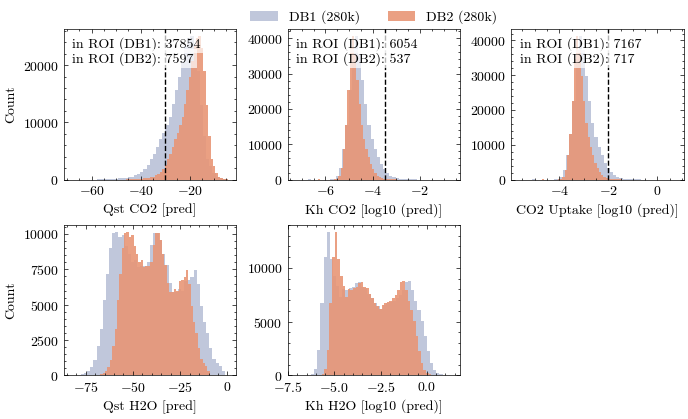

In [66]:
fig, axes = plt.subplots(2, 3, figsize=(8, 4.5))

def safe_log10(arr):
    a = np.array(arr)
    mask = a > 0
    return np.log10(a[mask]), mask

c1, _ = safe_log10(db1_co2_uptake["pred"])
c2, _ = safe_log10(db2_co2_uptake["pred"])
axes[0,2].hist(c1, bins=50, alpha=0.6, color=colors[0], label=f"DB1 (n={len(c1)})")
axes[0,2].hist(c2, bins=50, alpha=0.9, color=colors[2], label=f"DB2 (n={len(c2)})")
axes[0,2].set_xlabel("CO2 Uptake [log10 (pred)]")
axes[0,0].set_ylabel("Count")

k1, _ = safe_log10(db1_kh_co2["pred"])
k2, _ = safe_log10(db2_kh_co2["pred"])
axes[0,1].hist(k1, bins=50, alpha=0.6, color=colors[0], label=f"DB1 (280k)")
axes[0,1].hist(k2, bins=50, alpha=0.9, color=colors[2], label=f"DB2 (280k)")
axes[0,1].set_xlabel("Kh CO2 [log10 (pred)]")
axes[0,1].legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.95))

q1 = np.array(db1_qst_co2["pred"])
q2 = np.array(db2_qst_co2["pred"])
axes[0,0].hist(q1, bins=50, alpha=0.6, color=colors[0], label=f"DB1 (n={len(q1)})")
axes[0,0].hist(q2, bins=50, alpha=0.9, color=colors[2], label=f"DB2 (n={len(q2)})")
axes[0,0].set_xlabel("Qst CO2 [pred]")

axes[0,2].axvline(REGION_OF_INTEREST['co2_uptake'][0], color='k', linestyle='--', lw=1)
axes[0,1].axvline(REGION_OF_INTEREST['kh_co2'][0], color='k', linestyle='--', lw=1)
axes[0,0].axvline(REGION_OF_INTEREST['qst_co2'][0], color='k', linestyle='--', lw=1)

axes[1,0].set_ylabel("Count")

k1, _ = safe_log10(db1_kh_h2o["pred"])
k2, _ = safe_log10(db2_kh_h2o["pred"])
axes[1,1].hist(k1, bins=50, alpha=0.6, color=colors[0])
axes[1,1].hist(k2, bins=50, alpha=0.9, color=colors[2])
axes[1,1].set_xlabel("Kh H2O [log10 (pred)]")
axes[1,1].legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.95))

q1 = np.array(db1_qst_h2o["pred"])
q2 = np.array(db2_qst_h2o["pred"])
axes[1,0].hist(q1, bins=50, alpha=0.6, color=colors[0])
axes[1,0].hist(q2, bins=50, alpha=0.9, color=colors[2])
axes[1,0].set_xlabel("Qst H2O [pred]")


axes[0,2].text(0.05, 0.95, s=f"in ROI (DB1): {len(below_co2_uptake_db1)}", transform=axes[0,2].transAxes, va="top", ha="left", bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
axes[0,2].text(0.05, 0.85, s=f"in ROI (DB2): {len(below_co2_uptake_db2)}", transform=axes[0,2].transAxes, va="top", ha="left", bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

axes[0,1].text(0.05, 0.95, s=f"in ROI (DB1): {len(below_kh_co2_db1)}", transform=axes[0,1].transAxes, va="top", ha="left", bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
axes[0,1].text(0.05, 0.85, s=f"in ROI (DB2): {len(below_kh_co2_db2)}", transform=axes[0,1].transAxes, va="top", ha="left", bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

axes[0,0].text(0.05, 0.95, s=f"in ROI (DB1): {len(below_qst_co2_db1)}", transform=axes[0,0].transAxes, va="top", ha="left", bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
axes[0,0].text(0.05, 0.85, s=f"in ROI (DB2): {len(below_qst_co2_db2)}", transform=axes[0,0].transAxes, va="top", ha="left", bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))



axes[1,2].axis('off')
fig.subplots_adjust(hspace=0.3, wspace=0.3)
# plt.tight_layout()
plt.savefig("../../temp/figures/300k_prediction_distributions.png", dpi=300)
plt.show()

In [6]:
# sort db1_co2_uptake by the 'pred' values (ascending) and store in a new variable
order = np.argsort(db1_co2_uptake['pred'])
sorted_db1_co2_uptake = {
    'sid': db1_co2_uptake['sid'][order],
    'pred': db1_co2_uptake['pred'][order],
    'order': order
}

# optional: inspect top/bottom entries
print("min pred:", sorted_db1_co2_uptake['pred'][0], "sid:", sorted_db1_co2_uptake['sid'][0])
print("max pred:", sorted_db1_co2_uptake['pred'][-1], "sid:", sorted_db1_co2_uptake['sid'][-1])

min pred: 2.3329253e-06 sid: m184-qtz-x-z
max pred: 5.5977726 sid: m253-vcc-z


In [7]:
# keep only the last 200 items from the already-sorted dict
n_keep = 200
total = len(sorted_db1_co2_uptake['pred'])
n_keep = min(n_keep, total)
start = total - n_keep

sorted_db1_co2_uptake_last200 = {
    'sid': sorted_db1_co2_uptake['sid'][start:],
    'pred': sorted_db1_co2_uptake['pred'][start:],
    'order': sorted_db1_co2_uptake['order'][start:],
}

# optionally overwrite the original variable
sorted_db1_co2_uptake_filtered = sorted_db1_co2_uptake_last200

# print(f"Kept {n_keep} / {total} items. New min pred: {sorted_db1_co2_uptake['pred'][0]}, max pred: {sorted_db1_co2_uptake['pred'][-1]}")

In [9]:
pd.DataFrame(sorted_db1_co2_uptake)#.to_csv('/home/ignaczg/projects/aramco_dac/temp/kaust_7_top200_db1_co2_uptake.csv', index=False)

,sid,pred,order
0,m184-qtz-x-z,0.000002,50329
1,m281-nfc-z,0.000003,99352
2,m715-uki-z,0.000003,226983
3,m214-rob-z,0.000003,66381
4,m303_fixedH-rob-z,0.000003,108531
...,...,...,...
270838,m18-o14-bcu-z,1.135598,48548
270839,m303_fixedH-o10-rob-z,1.337678,107226
270840,m36_fixedH-o335-bcu-z,1.373623,123573
270841,m253-o280-rob-z,2.206169,86164


# No Ground truth 1M Mof_transformer   

In [13]:
db1_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/predictions/mof_transformer/merged/co2_uptake_db_1.npz', allow_pickle=True)
db2_co2_uptake = np.load('/ibex/project/c2261/dac_iclr/predictions/mof_transformer/merged/co2_uptake_db_2.npz', allow_pickle=True)

db1_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/predictions/mof_transformer/merged/kh_co2_db_1.npz', allow_pickle=True)
db2_kh_co2 = np.load('/ibex/project/c2261/dac_iclr/predictions/mof_transformer/merged/kh_co2_db_2.npz', allow_pickle=True)

db1_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/predictions/mof_transformer/merged/qst_co2_db_1.npz', allow_pickle=True)
db2_qst_co2 = np.load('/ibex/project/c2261/dac_iclr/predictions/mof_transformer/merged/qst_co2_db_2.npz', allow_pickle=True)

db1_qst_h2o = np.load('/ibex/project/c2261/dac_iclr/predictions/mof_transformer/merged/qst_h2o_db_1.npz', allow_pickle=True)
db2_qst_h2o = np.load('/ibex/project/c2261/dac_iclr/predictions/mof_transformer/merged/qst_h2o_db_2.npz', allow_pickle=True)

db1_kh_h2o = np.load('/ibex/project/c2261/dac_iclr/predictions/mof_transformer/merged/kh_h2o_db_1.npz', allow_pickle=True)
db2_kh_h2o = np.load('/ibex/project/c2261/dac_iclr/predictions/mof_transformer/merged/kh_h2o_db_2.npz', allow_pickle=True)


In [14]:
vars_to_merge = [
    'db1_co2_uptake', 'db1_kh_co2', 'db1_kh_h2o', 'db1_qst_co2', 'db1_qst_h2o',
    'db2_co2_uptake', 'db2_kh_co2', 'db2_kh_h2o', 'db2_qst_co2', 'db2_qst_h2o',
]

dfs = []
for var in vars_to_merge:
    npz = globals().get(var, None)
    if npz is None:
        continue
    keys = getattr(npz, 'files', None) or list(npz.keys())
    if 'sid' not in keys:
        continue
    temp = pd.DataFrame({'sid': np.array(npz['sid']).astype(str)})
    for k in keys:
        if k == 'sid':
            continue
        colname = f"{var}_{k}"
        temp[colname] = np.array(npz[k])
    dfs.append(temp)

if not dfs:
    merged_npz = pd.DataFrame()
else:
    merged_npz = dfs[0].copy()
    for df in dfs[1:]:
        merged_npz = pd.merge(merged_npz, df, on='sid', how='outer')

try:
    if merged_npz['sid'].str.match(r'^\d+$').all():
        merged_npz['sid'] = merged_npz['sid'].astype(int)
except Exception:
    pass

print("Merged DataFrame shape:", merged_npz.shape)
print("Columns:", merged_npz.columns.tolist())
merged_npz.to_csv('../../temp/merged_predictions_mof_transformer.csv', index=False)

Merged DataFrame shape: (1105835, 11)
Columns: ['sid', 'db1_co2_uptake_pred', 'db1_kh_co2_pred', 'db1_kh_h2o_pred', 'db1_qst_co2_pred', 'db1_qst_h2o_pred', 'db2_co2_uptake_pred', 'db2_kh_co2_pred', 'db2_kh_h2o_pred', 'db2_qst_co2_pred', 'db2_qst_h2o_pred']


In [15]:
below_co2_uptake_db1 = db1_co2_uptake['pred'][np.log10(db1_co2_uptake["pred"]) > REGION_OF_INTEREST['co2_uptake'][0]]
below_co2_uptake_db2 = db2_co2_uptake['pred'][np.log10(db2_co2_uptake["pred"]) > REGION_OF_INTEREST['co2_uptake'][0]]

below_kh_co2_db1 = db1_kh_co2['pred'][np.log10(db1_kh_co2["pred"]) > REGION_OF_INTEREST['kh_co2'][0]]
below_kh_co2_db2 = db2_kh_co2['pred'][np.log10(db2_kh_co2["pred"]) > REGION_OF_INTEREST['kh_co2'][0]]

below_qst_co2_db1 = db1_qst_co2['pred'][db1_qst_co2["pred"] < REGION_OF_INTEREST['qst_co2'][0]]
below_qst_co2_db2 = db2_qst_co2['pred'][db2_qst_co2["pred"] < REGION_OF_INTEREST['qst_co2'][0]]

In [16]:
print(len(merged_npz))
merged_npz_filtered = merged_npz[
    (np.log10(merged_npz['db1_co2_uptake_pred']) > REGION_OF_INTEREST['co2_uptake'][0]) &
    # (np.log10(merged_npz['db2_co2_uptake_pred']) > REGION_OF_INTEREST['co2_uptake'][0]) 
    (np.log10(merged_npz['db1_kh_co2_pred']) > REGION_OF_INTEREST['kh_co2'][0]) &
    # (np.log10(merged_npz['db2_kh_co2_pred']) > REGION_OF_INTEREST['kh_co2'][0]) &
    (merged_npz['db1_qst_co2_pred'] < REGION_OF_INTEREST['qst_co2'][0]) &
    # (merged_npz['db2_qst_co2_pred'] < REGION_OF_INTEREST['qst_co2'][0]) &
    (merged_npz['db1_qst_h2o_pred'] < REGION_OF_INTEREST['qst_h2o'][0]) &
    # (merged_npz['db2_qst_h2o_pred'] < REGION_OF_INTEREST['qst_h2o'][0]) &
    (np.log10(merged_npz['db1_kh_h2o_pred']) > REGION_OF_INTEREST['kh_h2o'][0])
    # (np.log10(merged_npz['db2_kh_h2o_pred']) > REGION_OF_INTEREST['kh_h2o'][0])
]

print(len(merged_npz_filtered), "entries after filtering for ROI")

1105835
25244 entries after filtering for ROI


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


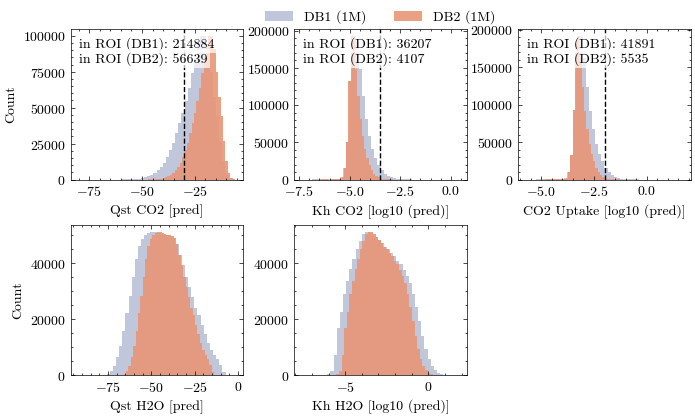

In [70]:
fig, axes = plt.subplots(2, 3, figsize=(8, 4.5))

def safe_log10(arr):
    a = np.array(arr)
    mask = a > 0
    return np.log10(a[mask]), mask

c1, _ = safe_log10(db1_co2_uptake["pred"])
c2, _ = safe_log10(db2_co2_uptake["pred"])
axes[0,2].hist(c1, bins=50, alpha=0.6, color=colors[0], label=f"DB1 (n={len(c1)})")
axes[0,2].hist(c2, bins=50, alpha=0.9, color=colors[2], label=f"DB2 (n={len(c2)})")
axes[0,2].set_xlabel("CO2 Uptake [log10 (pred)]")
axes[0,0].set_ylabel("Count")

k1, _ = safe_log10(db1_kh_co2["pred"])
k2, _ = safe_log10(db2_kh_co2["pred"])
axes[0,1].hist(k1, bins=50, alpha=0.6, color=colors[0], label=f"DB1 (1M)")
axes[0,1].hist(k2, bins=50, alpha=0.9, color=colors[2], label=f"DB2 (1M)")
axes[0,1].set_xlabel("Kh CO2 [log10 (pred)]")
axes[0,1].legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.95))

q1 = np.array(db1_qst_co2["pred"])
q2 = np.array(db2_qst_co2["pred"])
axes[0,0].hist(q1, bins=50, alpha=0.6, color=colors[0], label=f"DB1 (n={len(q1)})")
axes[0,0].hist(q2, bins=50, alpha=0.9, color=colors[2], label=f"DB2 (n={len(q2)})")
axes[0,0].set_xlabel("Qst CO2 [pred]")

axes[0,2].axvline(REGION_OF_INTEREST['co2_uptake'][0], color='k', linestyle='--', lw=1)
axes[0,1].axvline(REGION_OF_INTEREST['kh_co2'][0], color='k', linestyle='--', lw=1)
axes[0,0].axvline(REGION_OF_INTEREST['qst_co2'][0], color='k', linestyle='--', lw=1)

axes[1,0].set_ylabel("Count")

k1, _ = safe_log10(db1_kh_h2o["pred"])
k2, _ = safe_log10(db2_kh_h2o["pred"])
axes[1,1].hist(k1, bins=50, alpha=0.6, color=colors[0])
axes[1,1].hist(k2, bins=50, alpha=0.9, color=colors[2])
axes[1,1].set_xlabel("Kh H2O [log10 (pred)]")
axes[1,1].legend(loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.95))

q1 = np.array(db1_qst_h2o["pred"])
q2 = np.array(db2_qst_h2o["pred"])
axes[1,0].hist(q1, bins=50, alpha=0.6, color=colors[0])
axes[1,0].hist(q2, bins=50, alpha=0.9, color=colors[2])
axes[1,0].set_xlabel("Qst H2O [pred]")


axes[0,2].text(0.05, 0.95, s=f"in ROI (DB1): {len(below_co2_uptake_db1)}", transform=axes[0,2].transAxes, va="top", ha="left", bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
axes[0,2].text(0.05, 0.85, s=f"in ROI (DB2): {len(below_co2_uptake_db2)}", transform=axes[0,2].transAxes, va="top", ha="left", bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

axes[0,1].text(0.05, 0.95, s=f"in ROI (DB1): {len(below_kh_co2_db1)}", transform=axes[0,1].transAxes, va="top", ha="left", bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
axes[0,1].text(0.05, 0.85, s=f"in ROI (DB2): {len(below_kh_co2_db2)}", transform=axes[0,1].transAxes, va="top", ha="left", bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))

axes[0,0].text(0.05, 0.95, s=f"in ROI (DB1): {len(below_qst_co2_db1)}", transform=axes[0,0].transAxes, va="top", ha="left", bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))
axes[0,0].text(0.05, 0.85, s=f"in ROI (DB2): {len(below_qst_co2_db2)}", transform=axes[0,0].transAxes, va="top", ha="left", bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=2))



axes[1,2].axis('off')
fig.subplots_adjust(hspace=0.3, wspace=0.3)
# plt.tight_layout()
plt.savefig("../../temp/figures/1M_prediction_distributions.png", dpi=300)
plt.show()

In [17]:
db1_co2_uptake = db2_co2_uptake
order = np.argsort(db1_co2_uptake['pred'])
sorted_db1_co2_uptake = {
    'sid': db1_co2_uptake['sid'][order],
    'pred': db1_co2_uptake['pred'][order],
    'order': order
}

# optional: inspect top/bottom entries
print("min pred:", sorted_db1_co2_uptake['pred'][0], "sid:", sorted_db1_co2_uptake['sid'][0])
print("max pred:", sorted_db1_co2_uptake['pred'][-1], "sid:", sorted_db1_co2_uptake['sid'][-1])

min pred: 7.101696e-06 sid: cds-b+N317+N62+E0
max pred: 1.8516248 sid: tsi+N375+E0


In [5]:
# keep only the last 200 items from the already-sorted dict
n_keep = 200
total = len(sorted_db1_co2_uptake['pred'])
n_keep = min(n_keep, total)
start = total - n_keep

sorted_db1_co2_uptake_last200 = {
    'sid': sorted_db1_co2_uptake['sid'][start:],
    'pred': sorted_db1_co2_uptake['pred'][start:],
    'order': sorted_db1_co2_uptake['order'][start:],
}

# optionally overwrite the original variable
sorted_db1_co2_uptake_filtered = sorted_db1_co2_uptake_last200

# print(f"Kept {n_keep} / {total} items. New min pred: {sorted_db1_co2_uptake['pred'][0]}, max pred: {sorted_db1_co2_uptake['pred'][-1]}")

In [23]:
merged_npz[merged_npz['sid']=='mok+N276+E0']

,sid,db1_co2_uptake_pred,db1_kh_co2_pred,db1_kh_h2o_pred,db1_qst_co2_pred,db1_qst_h2o_pred,db2_co2_uptake_pred,db2_kh_co2_pred,db2_kh_h2o_pred,db2_qst_co2_pred,db2_qst_h2o_pred
353631,mok+N276+E0,1.609377,0.096332,0.000996,-62.779861,-44.359344,0.148838,0.006428,0.001066,-49.67527,-42.069878


In [49]:
gt.columns

Index(['MOF_ID', 'Qst_CO2_kJmol-1', 'Error_Qst_CO2_kJmol-1',
       'CO2_KH_molkg-1Pa-1', 'Error_CO2_KH_molkg-1Pa-1', 'Qst_H2O_kJmol-1',
       'Error_Qst_H2O_kJmol-1', 'H2O_KH_molkg-1Pa-1',
       'Error_H2O_KH_molkg-1Pa-1', 'CO2_uptake_mmolg-1'],
      dtype='object')

In [54]:
gt = pd.read_csv('../../temp/gt_wp1.csv')
print(len(gt))
gt.dropna(inplace=True)
print(len(gt))
gt = gt[gt['CO2_KH_molkg-1Pa-1'] > 0.0].copy()
gt = gt[gt['CO2_uptake_mmolg-1'] > 0.0].copy()
gt = gt[gt['H2O_KH_molkg-1Pa-1'] > 0.0].copy()
print(len(gt))

1000
997
996


In [55]:
l = []
for i in gt['MOF_ID']:
    l.append(str(i[:-7]))

In [56]:
gt['sid'] = l

In [57]:
merged_npz_gt = pd.merge(merged_npz, gt, on='sid', how='inner')

MAE (log10) = 0.136080 over 996 samples


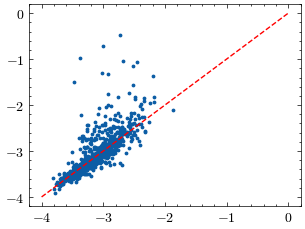

In [58]:
plt.scatter(np.log10(merged_npz_gt['db2_co2_uptake_pred']), np.log10(merged_npz_gt['CO2_uptake_mmolg-1']), s=3)
x = np.log10(merged_npz_gt['db2_co2_uptake_pred'].astype(float).values)
y = np.log10(merged_npz_gt['CO2_uptake_mmolg-1'].astype(float).values)
mask = np.isfinite(x) & np.isfinite(y)

if mask.sum() == 0:
    print("No valid pairs to compute MAE")
else:
    mae = np.mean(np.abs(x[mask] - y[mask]))
    print(f"MAE (log10) = {mae:.6f} over {mask.sum()} samples")
plt.plot([-4,0], [-4,0], color='red', linestyle='--')

In [33]:
merged_npz_gt.columns

Index(['sid', 'db1_co2_uptake_pred', 'db1_kh_co2_pred', 'db1_kh_h2o_pred',
       'db1_qst_co2_pred', 'db1_qst_h2o_pred', 'db2_co2_uptake_pred',
       'db2_kh_co2_pred', 'db2_kh_h2o_pred', 'db2_qst_co2_pred',
       'db2_qst_h2o_pred', 'MOF_ID', 'Qst_CO2_kJmol-1',
       'Error_Qst_CO2_kJmol-1', 'CO2_KH_molkg-1Pa-1',
       'Error_CO2_KH_molkg-1Pa-1', 'Qst_H2O_kJmol-1', 'Error_Qst_H2O_kJmol-1',
       'H2O_KH_molkg-1Pa-1', 'Error_H2O_KH_molkg-1Pa-1', 'CO2_uptake_mmolg-1'],
      dtype='object')

Qst CO2 DB1 R2: 0.4663
Kh CO2 DB1 R2: 0.4414
CO2 Uptake DB1 R2: 0.4912
Qst H2O DB1 R2: 0.6541
Kh H2O DB1 R2: 0.4736
Qst CO2 DB2 R2: 0.6540
Kh CO2 DB2 R2: 0.5781
CO2 Uptake DB2 R2: 0.5886
Qst H2O DB2 R2: -0.1781
Kh H2O DB2 R2: 0.4473


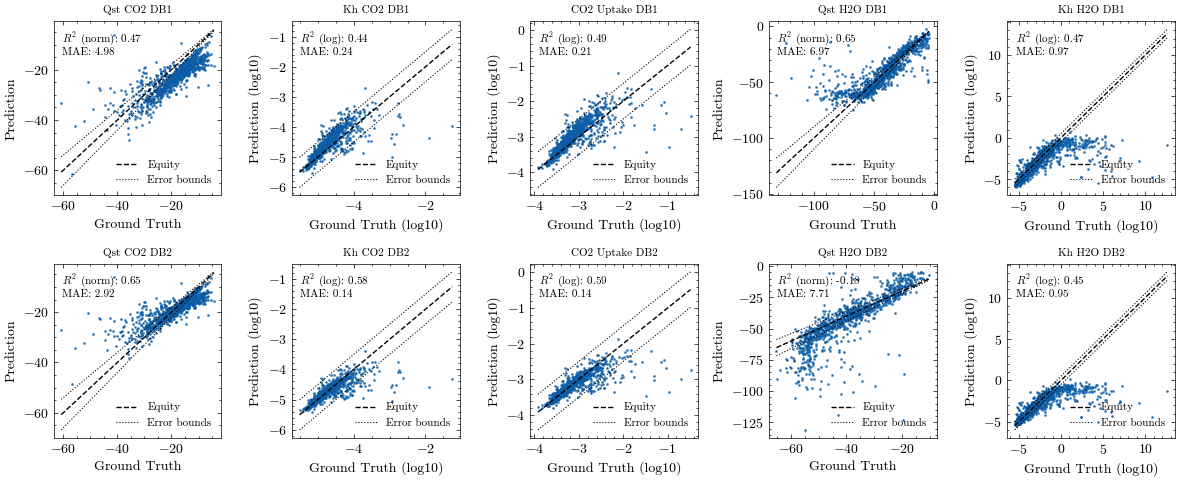

In [92]:
fig, axes = plt.subplots(2, 5, figsize=(12,5))

plot_equity_with_band(
    axes[0,0], 
    pred=merged_npz_gt['db1_qst_co2_pred'],
    gt=merged_npz_gt['Qst_CO2_kJmol-1'],
    key=None,
    title="Qst CO2 DB1",
    log=False,
)

plot_equity_with_band(
    axes[0,1], 
    pred=np.log10(merged_npz_gt[merged_npz_gt['db1_kh_co2_pred'] > 0]['db1_kh_co2_pred']),
    gt  =np.log10(merged_npz_gt[merged_npz_gt['CO2_KH_molkg-1Pa-1'] > 0]['CO2_KH_molkg-1Pa-1']),
    key=None,
    title="Kh CO2 DB1",
    log=True,
)

plot_equity_with_band(
    axes[0,2], 
    pred=np.log10(merged_npz_gt[merged_npz_gt['db1_co2_uptake_pred'] > 0]['db1_co2_uptake_pred']),
    gt  =np.log10(merged_npz_gt[merged_npz_gt['CO2_uptake_mmolg-1'] > 0]['CO2_uptake_mmolg-1']),
    key=None,
    title="CO2 Uptake DB1",
    log=True,
)

plot_equity_with_band(
    axes[0,3], 
    pred=merged_npz_gt['db1_qst_h2o_pred'],
    gt  =merged_npz_gt['Qst_H2O_kJmol-1'],
    key=None,
    title="Qst H2O DB1",
    log=False,
)

plot_equity_with_band(
    axes[0,4], 
    pred=np.log10(merged_npz_gt[merged_npz_gt['db1_kh_h2o_pred'] > 0]['db1_kh_h2o_pred']),
    gt  =np.log10(merged_npz_gt[merged_npz_gt['H2O_KH_molkg-1Pa-1'] > 0]['H2O_KH_molkg-1Pa-1']),
    key=None,
    title="Kh H2O DB1",
    log=True,
)


plot_equity_with_band(
    axes[1,0], 
    pred=merged_npz_gt['db2_qst_co2_pred'],
    gt  =merged_npz_gt['Qst_CO2_kJmol-1'],
    key=None,
    title="Qst CO2 DB2",
    log=False,
)

plot_equity_with_band(
    axes[1,1], 
    pred=np.log10(merged_npz_gt[merged_npz_gt['db2_kh_co2_pred'] > 0]['db2_kh_co2_pred']),
    gt  =np.log10(merged_npz_gt[merged_npz_gt['CO2_KH_molkg-1Pa-1'] > 0]['CO2_KH_molkg-1Pa-1']),
    key=None,
    title="Kh CO2 DB2",
    log=True,
)

plot_equity_with_band(
    axes[1,2], 
    pred=np.log10(merged_npz_gt[merged_npz_gt['db2_co2_uptake_pred'] > 0]['db2_co2_uptake_pred']),
    gt  =np.log10(merged_npz_gt[merged_npz_gt['CO2_uptake_mmolg-1'] > 0]['CO2_uptake_mmolg-1']),
    key=None,
    title="CO2 Uptake DB2",
    log=True,
)

plot_equity_with_band(
    axes[1,3], 
    pred=merged_npz_gt['Qst_H2O_kJmol-1'],
    gt  =merged_npz_gt['db2_qst_h2o_pred'],
    key=None,
    title="Qst H2O DB2",
    log=False,
)

plot_equity_with_band(
    axes[1,4], 
    pred=np.log10(merged_npz_gt[merged_npz_gt['db2_kh_h2o_pred'] > 0]['db2_kh_h2o_pred']),
    gt  =np.log10(merged_npz_gt[merged_npz_gt['H2O_KH_molkg-1Pa-1'] > 0]['H2O_KH_molkg-1Pa-1']),
    key=None,
    title="Kh H2O DB2",
    log=True,
)


plt.tight_layout()
plt.savefig("../../temp/figures/equity_plots_300k_gt_vs_pred.png", dpi=300)
plt.show()

# Autoregressive pretraining finetuning results 

In [6]:
results = {
    'qst_co2': [0.071, 0.062, 0.051],        
    'kh_co2':  [0.41, 0.36, 0.29],        
    'co2_uptake': [0.42, 0.38, 0.3],        
    'qst_h2o': [0.16, 0.14, 0.13],        
    'kh_h2o':  [0.96, 0.88, 0.81],
}
budget = [2, 36]

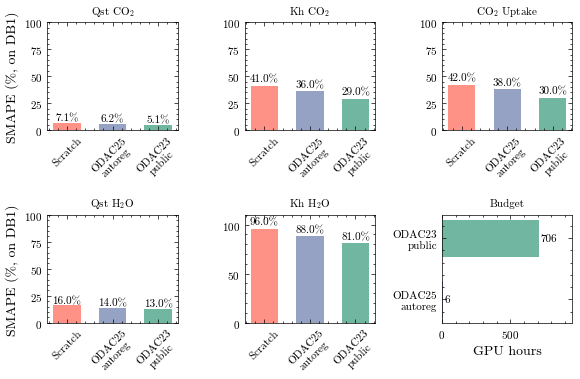

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(6, 4))

# Data and Labels
# Models for 3-bar plots: Scratch, ODAC25 autoreg, ODAC23 public
labels_3 = ['Scratch', 'ODAC25\nautoreg', 'ODAC23\npublic']
colors_3 = [colors[4], colors[0], colors[3]]

# Models for Budget (2-bar) plot: Autoreg, Public
labels_2 = ['ODAC25\nautoreg', 'ODAC23\npublic']
colors_2 = [colors[0], colors[3]]

# ---------------------------------------------------------
# Row 1
# ---------------------------------------------------------

# 1. Qst CO2
values = [7.1, 6.2, 5.1]
axes[0, 0].bar(labels_3, values, color=colors_3, width=0.6)
for i, v in enumerate(values):
    axes[0, 0].text(i, v + 0.4, f"{v:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[0, 0].set_ylim(0, 100)
axes[0, 0].set_ylabel("SMAPE (%, on DB1)")
axes[0, 0].set_title("Qst CO$_2$", fontsize=8)

# 2. Kh CO2
values = [41.0, 36.0, 29.0]
axes[0, 1].bar(labels_3, values, color=colors_3, width=0.6)
for i, v in enumerate(values):
    axes[0, 1].text(i, v + 2, f"{v:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[0, 1].set_ylim(0, 100)
axes[0, 1].set_title("Kh CO$_2$", fontsize=8)

# 3. CO2 Uptake
values = [42.0, 38.0, 30.0]
axes[0, 2].bar(labels_3, values, color=colors_3, width=0.6)
for i, v in enumerate(values):
    axes[0, 2].text(i, v + 2, f"{v:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[0, 2].set_ylim(0, 100)
axes[0, 2].set_title("CO$_2$ Uptake", fontsize=8)

# ---------------------------------------------------------
# Row 2
# ---------------------------------------------------------

# 4. Qst H2O
values = [16.0, 14.0, 13.0]
axes[1, 0].bar(labels_3, values, color=colors_3, width=0.6)
for i, v in enumerate(values):
    axes[1, 0].text(i, v + 0.4, f"{v:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1, 0].set_ylim(0, 100)
axes[1, 0].set_ylabel("SMAPE (%, on DB1)")
axes[1, 0].set_title("Qst H$_2$O", fontsize=8)

# 5. Kh H2O
values = [96.0, 88.0, 81.0]
axes[1, 1].bar(labels_3, values, color=colors_3, width=0.6)
for i, v in enumerate(values):
    axes[1, 1].text(i, v + 2, f"{v:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1, 1].set_ylim(0, 110)
axes[1, 1].set_title("Kh H$_2$O", fontsize=8)

# 6. Budget (Horizontal)
values = [6, 706]
axes[1, 2].barh(labels_2, values, color=colors_2, height=0.6)
for i, v in enumerate(values):
    axes[1, 2].text(v + 10, i, f"{v}", ha='left', va='center', fontsize=8, fontweight='bold')
axes[1, 2].set_xlim(0, max(values) * 1.35)
axes[1, 2].set_xlabel("Sample size")
axes[1, 2].set_title("Budget", fontsize=8)

# Formatting
for i, ax in enumerate(axes.flat):
    if i != 5: # All except the last plot (Budget)
        ax.tick_params(axis='x', labelrotation=45, labelsize=8)
    else:
        ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig("../../temp/figures/co2_uptake_comparison_dec_autoreg_v2.png", dpi=300, bbox_inches='tight')

plt.show()